# Model Comparison Summary

Comparing 6 different model configurations:
1. **RAW + Dual Model LSTM** - Time domain features with CPD + HI models
2. **RAW + Single Model LSTM** - Time domain features with single HI model
3. **FFT + Dual Model LSTM** - Frequency domain features with CPD + HI models
4. **FFT + Single Model LSTM** - Frequency domain features with single HI model
5. **RAW + GRU** (formerly Single GRU) - Time domain features with single HI model
6. **FFT + GRU** (formerly Single GRU) - Frequency domain features with single HI model

*Note: Dual GRU models have been removed from this comparison.*

## Configuration

In [27]:
ROOT_PROJECT_DATASET = "/home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing"
BEARING_NAME = "bearing_1"
DATASET_PATH = f"{ROOT_PROJECT_DATASET}/{BEARING_NAME}/datasets"

# Frequency range for FFT models
FREQUENCY_MIN, FREQUENCY_MAX =220, 260

BEARING_LIFESPAN_TIME = 392_275
TURNING_POINT_TIME = 290000

## Import Libraries

In [28]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scientific Plotting Style (White Background + Minor Ticks)
plt.style.use('default')  # Start with default white background
sns.set_palette("husl")

# Configure global matplotlib parameters for publication-quality figures
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'grid.color': '#bfbfbf',
    
    # Tick settings
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.top': True,
    'ytick.right': True,
    
    # Font sizes
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': 'black'
})

## Load Training Logs

In [29]:
# Model configuration for 6 experiments (4 LSTM + 2 GRU)
MODEL_CONFIGS = [
    {'name': 'RAW Dual LSTM',   'domain': 'RAW', 'arch': 'Dual',   'family': 'LSTM', 'log_file': 'raw_dual_model_training_log.csv'},
    {'name': 'RAW Single LSTM', 'domain': 'RAW', 'arch': 'Single', 'family': 'LSTM', 'log_file': 'raw_single_model_training_log.csv'},
    {'name': 'FFT Dual LSTM',   'domain': 'FFT', 'arch': 'Dual',   'family': 'LSTM', 'log_file': 'fft_dual_model_training_log.csv'},
    {'name': 'FFT Single LSTM', 'domain': 'FFT', 'arch': 'Single', 'family': 'LSTM', 'log_file': 'fft_single_model_training_log.csv'},
    {'name': 'RAW GRU',         'domain': 'RAW', 'arch': 'Single', 'family': 'GRU',  'log_file': 'raw_single_gru_training_log.csv'},
    {'name': 'FFT GRU',         'domain': 'FFT', 'arch': 'Single', 'family': 'GRU',  'log_file': 'fft_single_gru_training_log.csv'}
]

# Load training logs
training_logs = {}
for cfg in MODEL_CONFIGS:
    training_logs[cfg['name']] = pd.read_csv(f"{DATASET_PATH}/{cfg['log_file']}")

print("Training Logs Loaded:")
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    print(f"  {model_name:<16}: {len(training_logs[model_name])} epochs")

# Backward-compatible aliases (used by older cells)
raw_dual_log = training_logs['RAW Dual LSTM']
raw_single_log = training_logs['RAW Single LSTM']
fft_dual_log = training_logs['FFT Dual LSTM']
fft_single_log = training_logs['FFT Single LSTM']
# QRU Aliases updated
raw_gru_log = training_logs['RAW GRU']
fft_gru_log = training_logs['FFT GRU']

Training Logs Loaded:
  RAW Dual LSTM   : 400 epochs
  RAW Single LSTM : 389 epochs
  FFT Dual LSTM   : 400 epochs
  FFT Single LSTM : 400 epochs
  RAW GRU         : 400 epochs
  FFT GRU         : 400 epochs


## Load Prediction Results

In [30]:
# Attach result and evaluation filenames to model configs
for cfg in MODEL_CONFIGS:
    prefix = cfg['domain'].lower()
    if cfg['family'] == 'LSTM':
        cfg['result_file'] = f"{prefix}_{cfg['arch'].lower()}_lstm_results.csv"
        cfg['eval_file'] = f"{prefix}_{cfg['arch'].lower()}_lstm_eval_metrics.csv"
    else:
        cfg['result_file'] = f"{prefix}_{cfg['arch'].lower()}_gru_results.csv"
        cfg['eval_file'] = f"{prefix}_{cfg['arch'].lower()}_gru_eval_metrics.csv"

# Load prediction results
prediction_results = {}
for cfg in MODEL_CONFIGS:
    prediction_results[cfg['name']] = pd.read_csv(f"{DATASET_PATH}/{cfg['result_file']}")

print("\nPrediction Results Loaded:")
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    print(f"  {model_name:<16}: {len(prediction_results[model_name])} predictions")

# Verify summary is loading from the same dataset folder used by training exports
print("\n" + "=" * 100)
print("PATH CONSISTENCY CHECK (TRAINING OUTPUTS vs SUMMARY LOAD PATH)")
print("=" * 100)
missing_files = []
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    log_path = Path(DATASET_PATH) / cfg['log_file']
    result_path = Path(DATASET_PATH) / cfg['result_file']
    eval_path = Path(DATASET_PATH) / cfg['eval_file']

    log_ok = log_path.exists()
    result_ok = result_path.exists()
    eval_ok = eval_path.exists()

    print(f"{model_name}")
    print(f"  log    : {log_path.name:<40} -> {'OK' if log_ok else 'MISSING'}")
    print(f"  result : {result_path.name:<40} -> {'OK' if result_ok else 'MISSING'}")
    print(f"  eval   : {eval_path.name:<40} -> {'OK' if eval_ok else 'MISSING'}")

    if not (log_ok and result_ok and eval_ok):
        missing_files.append({
            'model': model_name,
            'log': str(log_path),
            'result': str(result_path),
            'eval': str(eval_path),
        })

if missing_files:
    print("\nWARNING: Some expected files are missing. Ensure training notebooks have been run and outputs saved.")
else:
    print("\nAll expected training outputs were found in DATASET_PATH.")
print("=" * 100)

# Backward-compatible aliases (used by older cells)
raw_dual_results = prediction_results['RAW Dual LSTM']
raw_single_results = prediction_results['RAW Single LSTM']
fft_dual_results = prediction_results['FFT Dual LSTM']
fft_single_results = prediction_results['FFT Single LSTM']
# Aliases updated
raw_gru_results = prediction_results['RAW GRU']
fft_gru_results = prediction_results['FFT GRU']


Prediction Results Loaded:
  RAW Dual LSTM   : 525 predictions
  RAW Single LSTM : 525 predictions
  FFT Dual LSTM   : 524 predictions
  FFT Single LSTM : 524 predictions
  RAW GRU         : 525 predictions
  FFT GRU         : 524 predictions

PATH CONSISTENCY CHECK (TRAINING OUTPUTS vs SUMMARY LOAD PATH)
RAW Dual LSTM
  log    : raw_dual_model_training_log.csv          -> OK
  result : raw_dual_lstm_results.csv                -> OK
  eval   : raw_dual_lstm_eval_metrics.csv           -> OK
RAW Single LSTM
  log    : raw_single_model_training_log.csv        -> OK
  result : raw_single_lstm_results.csv              -> OK
  eval   : raw_single_lstm_eval_metrics.csv         -> OK
FFT Dual LSTM
  log    : fft_dual_model_training_log.csv          -> OK
  result : fft_dual_lstm_results.csv                -> OK
  eval   : fft_dual_lstm_eval_metrics.csv           -> OK
FFT Single LSTM
  log    : fft_single_model_training_log.csv        -> OK
  result : fft_single_lstm_results.csv              

## Helper Functions

In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_curve, auc

def asymmetric_loss_scoring_function(y_true, y_pred, a=10, b=13):
    """
    Asymmetric loss for regression (numpy version).
    Penalizes late predictions (under-predictions) more than early ones (over-predictions).
    For RUL prediction:
    - Early prediction (y_pred < y_true): smaller penalty - predicting shorter life than reality
    - Late prediction (y_pred >= y_true): larger penalty - predicting longer life than reality (more dangerous)
    
    Formula:
    loss = exp(-(y_pred - y_true)/a) - 1, if early (y_pred < y_true)
    loss = exp((y_pred - y_true)/b) - 1, if late (y_pred >= y_true)
    
    Args:
        y_true: Ground truth values
        y_pred: Predicted values
        a: Parameter controlling early prediction penalty (higher = more lenient)
        b: Parameter controlling late prediction penalty (lower = more strict)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    diff = y_pred - y_true
    
    # Calculate asymmetric loss
    loss = np.where(
        diff < 0,
        np.exp(-diff / a) - 1,   # Early prediction (over-prediction, smaller penalty)
        np.exp(diff / b) - 1     # Late prediction (under-prediction, larger penalty)
    )
    return np.mean(loss)

def calculate_metrics(y_true, y_pred):
    """
    Calculate comprehensive metrics for model evaluation
    
    Args:
        y_true: Ground truth values
        y_pred: Predicted values
        use_asymmetric: Whether to calculate asymmetric loss (default: True)
    """
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # RPE - Relative Prediction Error
    mask = y_true != 0
    rpe = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if np.any(mask) else 0
    asymmetric_loss = asymmetric_loss_scoring_function(y_true, y_pred)
    
    metrics = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'RPE (%)': rpe,
        'SF': asymmetric_loss
    }
    
    return metrics

def calculate_cpd_metrics(y_true, y_pred):
    """Calculate Change Point Detection metrics"""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    
    accuracy = (tp + tn) / len(y_true) if len(y_true) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

## 1. Training Performance Comparison

In [32]:
# Training Summary Table (6 models)
summary_rows = []
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    log_df = training_logs[model_name]
    row = {
        'Model': model_name,
        'Total Epochs': len(log_df),
        'Final HI Loss': log_df['hi_loss'].iloc[-1],
        'Best HI Loss': log_df['best_hi_loss'].min(),
        'Final HI RMSE': log_df['hi_rmse'].iloc[-1],
        'Final HI RPE (%)': log_df['hi_rpe'].iloc[-1],
        'Final CPD F1': log_df['cp_f1'].iloc[-1] if 'cp_f1' in log_df.columns else np.nan
    }
    summary_rows.append(row)

training_summary = pd.DataFrame(summary_rows)

print("="*100)
print("TRAINING PERFORMANCE SUMMARY")
print("="*100)
print(training_summary.to_string(index=False))
print("="*100)

TRAINING PERFORMANCE SUMMARY
          Model  Total Epochs  Final HI Loss  Best HI Loss  Final HI RMSE  Final HI RPE (%)  Final CPD F1
  RAW Dual LSTM           400       0.022288      0.021440       0.294859        268.608030           0.0
RAW Single LSTM           389       0.012876      0.012746       0.326402        165.566330           NaN
  FFT Dual LSTM           400       0.001779      0.001550       0.011844          7.702711           1.0
FFT Single LSTM           400       0.000959      0.000868       0.006946          3.349678           NaN
        RAW GRU           400       0.012831      0.012748       0.329290        166.733630           NaN
        FFT GRU           400       0.001013      0.000729       0.007673          4.567423           NaN


### Training Loss Curves

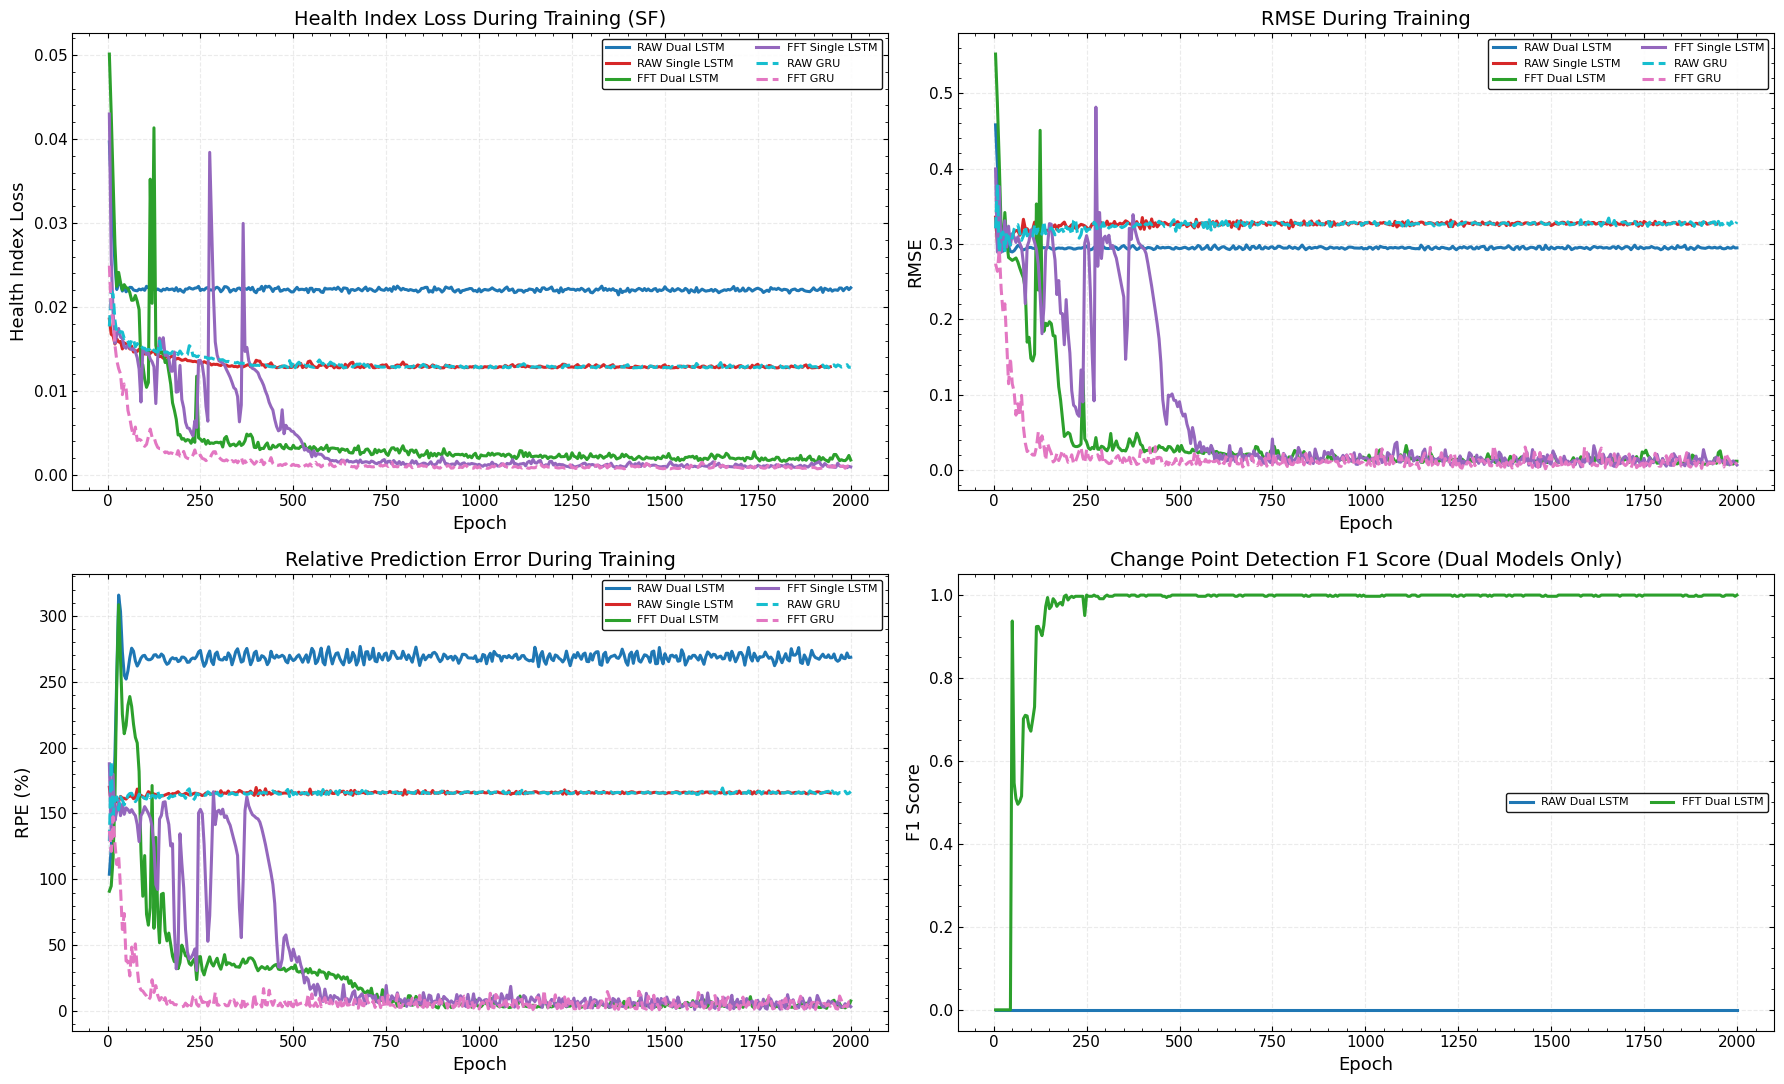

In [33]:
# High-contrast plotting styles for 6 models (article-friendly)
MODEL_STYLES = {
    'RAW Dual LSTM':   {'color': '#1f77b4', 'linestyle': '-'},   # blue
    'RAW Single LSTM': {'color': '#d62728', 'linestyle': '-'},   # red
    'FFT Dual LSTM':   {'color': '#2ca02c', 'linestyle': '-'},   # green
    'FFT Single LSTM': {'color': '#9467bd', 'linestyle': '-'},   # purple
    'RAW GRU':         {'color': '#17becf', 'linestyle': '--'},  # cyan
    'FFT GRU':         {'color': '#e377c2', 'linestyle': '--'}   # pink
}

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

# HI Loss Comparison
ax = axes[0, 0]
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    df = training_logs[model_name]
    ax.plot(df['epoch'], df['hi_loss'], label=model_name, linewidth=2.2,
            color=MODEL_STYLES[model_name]['color'],
            linestyle=MODEL_STYLES[model_name]['linestyle'])
ax.set_xlabel('Epoch')
ax.set_ylabel('Health Index Loss')
ax.set_title('Health Index Loss During Training (SF)')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# RMSE Comparison
ax = axes[0, 1]
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    df = training_logs[model_name]
    ax.plot(df['epoch'], df['hi_rmse'], label=model_name, linewidth=2.2,
            color=MODEL_STYLES[model_name]['color'],
            linestyle=MODEL_STYLES[model_name]['linestyle'])
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE')
ax.set_title('RMSE During Training')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# RPE Comparison
ax = axes[1, 0]
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    df = training_logs[model_name]
    ax.plot(df['epoch'], df['hi_rpe'], label=model_name, linewidth=2.2,
            color=MODEL_STYLES[model_name]['color'],
            linestyle=MODEL_STYLES[model_name]['linestyle'])
ax.set_xlabel('Epoch')
ax.set_ylabel('RPE (%)')
ax.set_title('Relative Prediction Error During Training')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# CPD F1 Score (dual models only)
ax = axes[1, 1]
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    if cfg['arch'] == 'Dual':
        df = training_logs[model_name]
        if 'cp_f1' in df.columns:
            ax.plot(df['epoch'], df['cp_f1'], label=model_name, linewidth=2.2,
                    color=MODEL_STYLES[model_name]['color'],
                    linestyle=MODEL_STYLES[model_name]['linestyle'])
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Change Point Detection F1 Score (Dual Models Only)')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Test Performance Comparison

In [34]:
# Calculate test metrics for all models (6 experiments)
test_rows = []
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    df = prediction_results[model_name]
    metrics = calculate_metrics(df['true_health_index'], df['predicted_health_index'])
    test_rows.append({
        'Model': model_name,
        'MSE': metrics['MSE'],
        'RMSE': metrics['RMSE'],
        'MAE': metrics['MAE'],
        'R²': metrics['R²'],
        'RPE (%)': metrics['RPE (%)'],
        'Asymmetric Loss': metrics['SF']
    })

test_comparison = pd.DataFrame(test_rows)

print("\n" + "="*100)
print("TEST PERFORMANCE METRICS (Health Index Prediction)")
print("="*100)
print(test_comparison.to_string(index=False))
print("="*100)


TEST PERFORMANCE METRICS (Health Index Prediction)
          Model      MSE     RMSE      MAE        R²    RPE (%)  Asymmetric Loss
  RAW Dual LSTM 0.108622 0.329578 0.162736 -0.322419 250.759941         0.012846
RAW Single LSTM 0.107687 0.328158 0.163753 -0.311043 250.135310         0.012966
  FFT Dual LSTM 0.000046 0.006759 0.003434  0.999443   3.698374         0.000269
FFT Single LSTM 0.000048 0.006945 0.005084  0.999412   4.534399         0.000451
        RAW GRU 0.109596 0.331053 0.165703 -0.334282 251.800599         0.013077
        FFT GRU 0.000060 0.007762 0.004084  0.999265   6.967146         0.000335


### Change Point Detection Performance (Dual Models Only)

In [35]:
# CPD metrics for dual models (LSTM + GRU)
cpd_rows = []
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    if cfg['arch'] != 'Dual':
        continue

    df = prediction_results[model_name]
    if 'cpd_binary' in df.columns and 'true_cpd_binary' in df.columns:
        cpd = calculate_cpd_metrics(df['true_cpd_binary'], df['cpd_binary'])
        cpd_rows.append({
            'Model': model_name,
            'Accuracy': cpd['Accuracy'],
            'Precision': cpd['Precision'],
            'Recall': cpd['Recall'],
            'F1-Score': cpd['F1-Score']
        })

if cpd_rows:
    cpd_comparison = pd.DataFrame(cpd_rows)
    print("\n" + "="*100)
    print("CHANGE POINT DETECTION PERFORMANCE (Dual Models Only)")
    print("="*100)
    print(cpd_comparison.to_string(index=False))
    print("="*100)
else:
    print("\nNo CPD metrics available in the results files.")


CHANGE POINT DETECTION PERFORMANCE (Dual Models Only)
        Model  Accuracy  Precision  Recall  F1-Score
RAW Dual LSTM  0.674286        0.0     0.0       0.0
FFT Dual LSTM  1.000000        1.0     1.0       1.0


### ROC Curve for Change Point Detection (Dual Models)

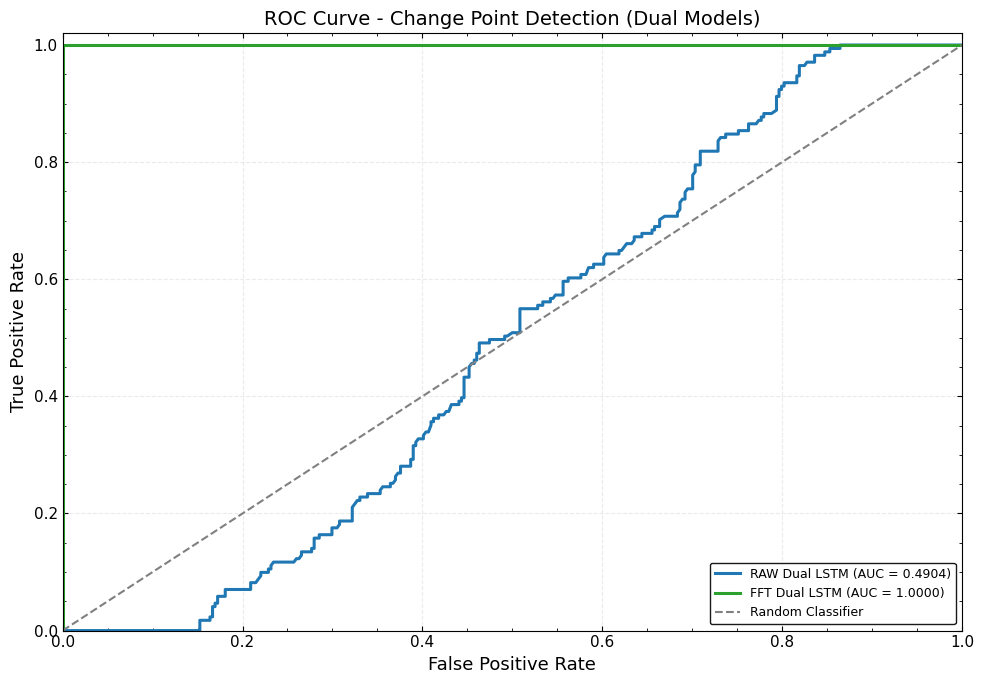


CPD ROC-AUC COMPARISON (Dual Models)
        Model      AUC
FFT Dual LSTM 1.000000
RAW Dual LSTM 0.490443


In [36]:
# ROC visualization for CPD (dual models only)
roc_rows = []
plt.figure(figsize=(10, 7))

for cfg in MODEL_CONFIGS:
    if cfg['arch'] != 'Dual':
        continue

    model_name = cfg['name']
    df = prediction_results[model_name]

    if 'true_cpd_binary' not in df.columns or 'cpd_probability' not in df.columns:
        continue

    y_true = df['true_cpd_binary'].astype(int).values
    y_score = df['cpd_probability'].values

    # ROC is undefined if only one class appears in y_true
    if len(np.unique(y_true)) < 2:
        continue

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    roc_rows.append({'Model': model_name, 'AUC': roc_auc})

    plt.plot(
        fpr, tpr,
        label=f"{model_name} (AUC = {roc_auc:.4f})",
        color=MODEL_STYLES[model_name]['color'],
        linestyle=MODEL_STYLES[model_name]['linestyle'],
        linewidth=2.2
    )

# Random baseline
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Change Point Detection (Dual Models)')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

if roc_rows:
    roc_comparison = pd.DataFrame(roc_rows).sort_values('AUC', ascending=False)
    print("\n" + "=" * 100)
    print("CPD ROC-AUC COMPARISON (Dual Models)")
    print("=" * 100)
    print(roc_comparison.to_string(index=False))
    print("=" * 100)
else:
    print("\nNo valid ROC curve could be generated (missing columns or single-class ground truth).")

### Test Performance Bar Charts

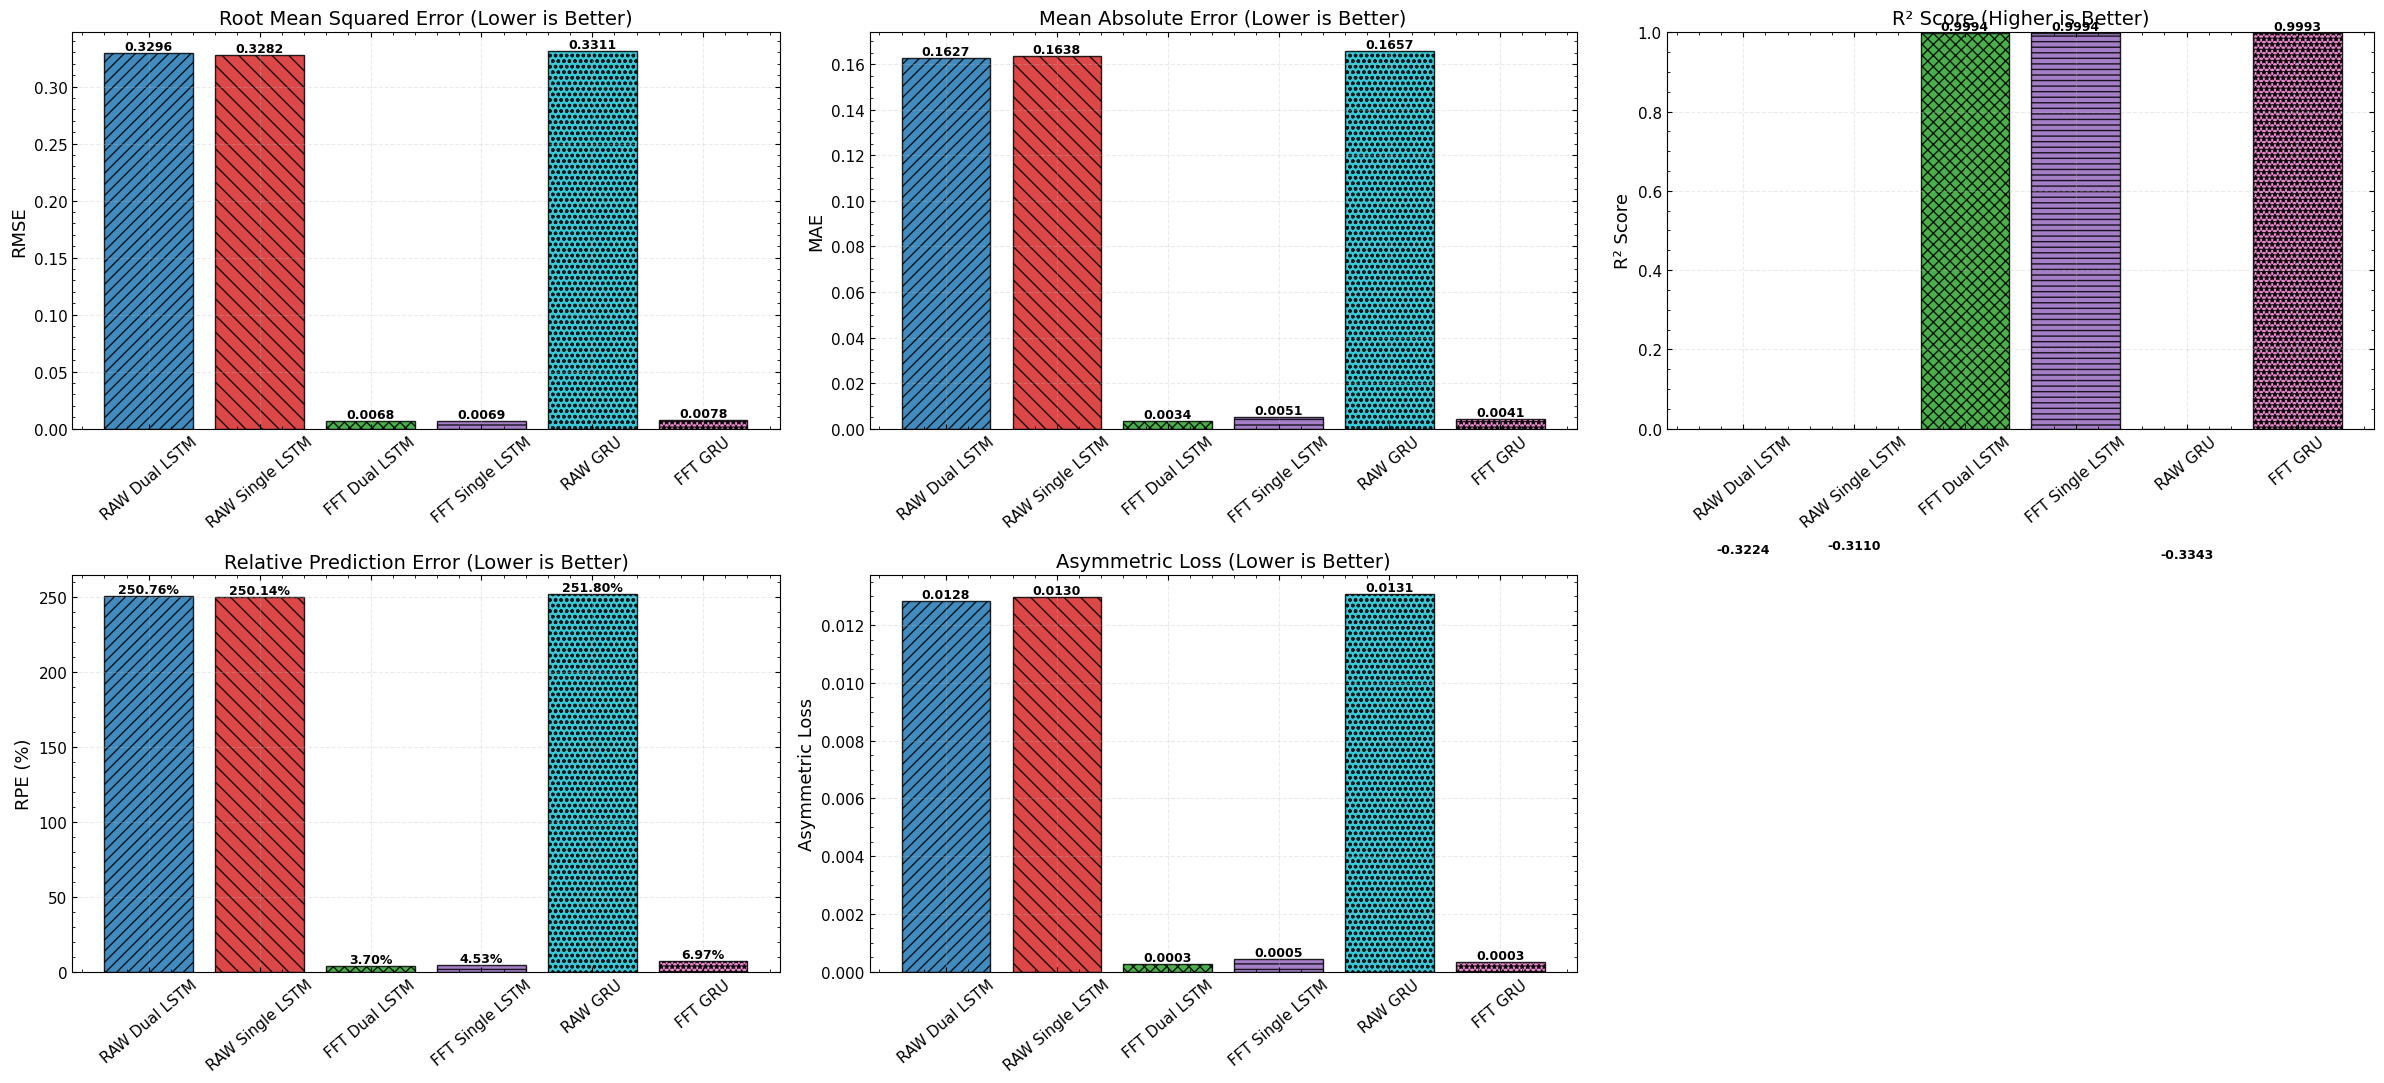

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(24, 11))

models = test_comparison['Model'].tolist()
model_colors = [MODEL_STYLES[m]['color'] for m in models]
model_hatches = {
    'RAW Dual LSTM': '///',
    'RAW Single LSTM': '\\\\',
    'FFT Dual LSTM': 'xxx',
    'FFT Single LSTM': '---',
    'RAW GRU': 'ooo',
    'FFT GRU': '***'
}

def _plot_metric_bar(ax, values, ylabel, title, fmt='{:.4f}', ylim=None):
    bars = ax.bar(models, values, color=model_colors, alpha=0.85, edgecolor='black', linewidth=1.0)
    for bar, model_name in zip(bars, models):
        bar.set_hatch(model_hatches[model_name])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=40)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt.format(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

# RMSE
_plot_metric_bar(
    axes[0, 0],
    test_comparison['RMSE'].values,
    'RMSE',
    'Root Mean Squared Error (Lower is Better)',
    fmt='{:.4f}'
)

# MAE
_plot_metric_bar(
    axes[0, 1],
    test_comparison['MAE'].values,
    'MAE',
    'Mean Absolute Error (Lower is Better)',
    fmt='{:.4f}'
)

# R²
_plot_metric_bar(
    axes[0, 2],
    test_comparison['R²'].values,
    'R² Score',
    'R² Score (Higher is Better)',
    fmt='{:.4f}',
    ylim=(0, 1)
)

# RPE
_plot_metric_bar(
    axes[1, 0],
    test_comparison['RPE (%)'].values,
    'RPE (%)',
    'Relative Prediction Error (Lower is Better)',
    fmt='{:.2f}%'
)

# Asymmetric Loss
_plot_metric_bar(
    axes[1, 1],
    test_comparison['Asymmetric Loss'].values,
    'Asymmetric Loss',
    'Asymmetric Loss (Lower is Better)',
    fmt='{:.4f}'
)

# Hide unused subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## 3. Health Index Prediction Visualization

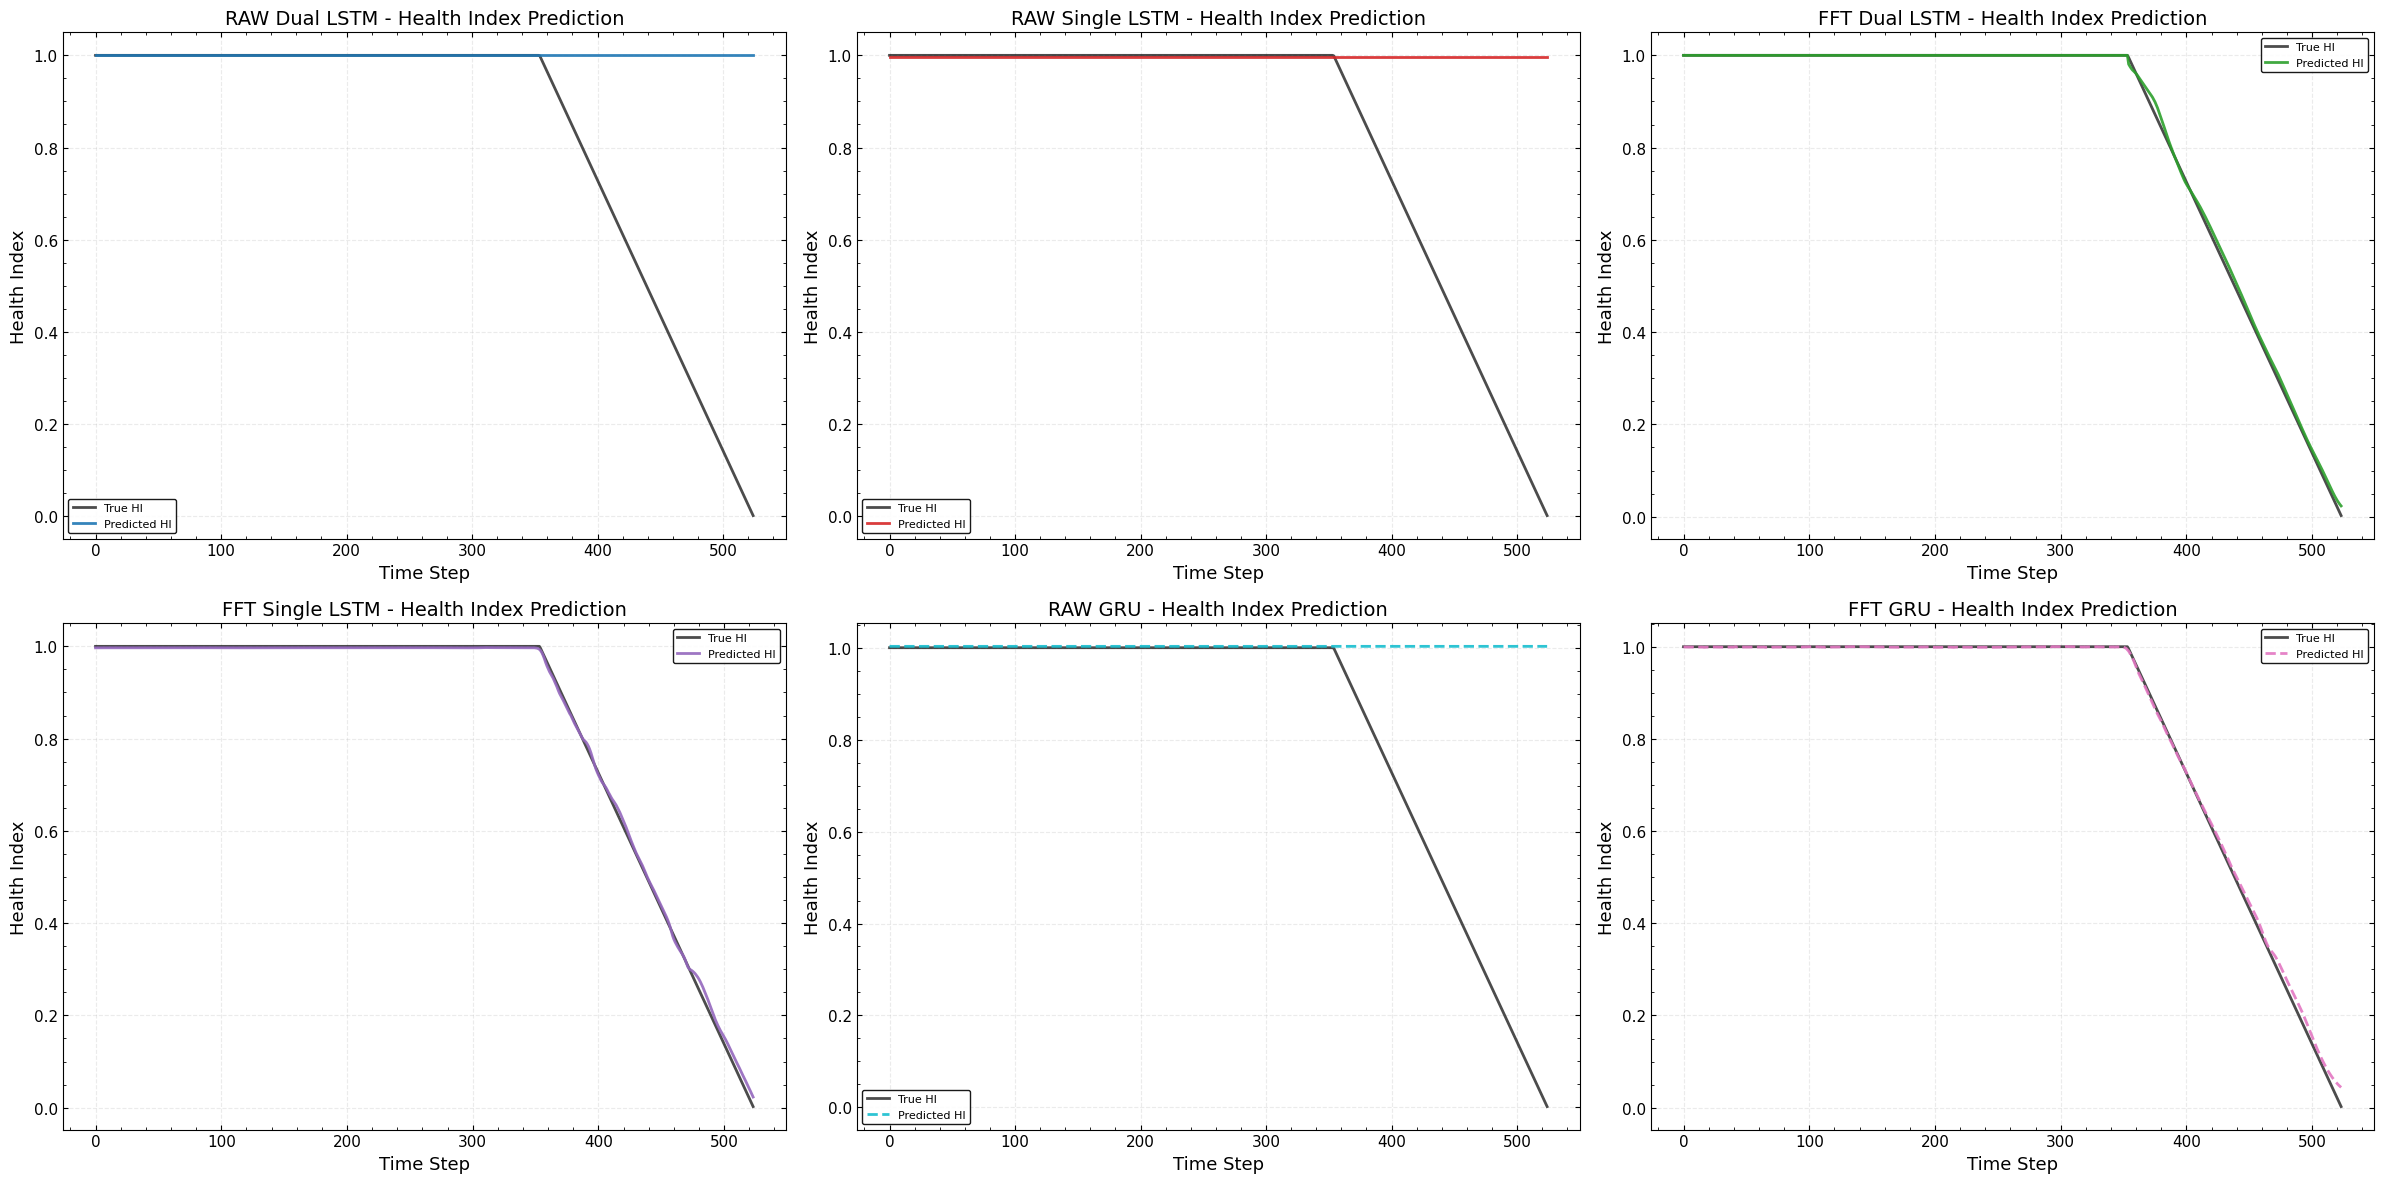

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(24, 12))
axes = axes.flatten()

for idx, cfg in enumerate(MODEL_CONFIGS):
    model_name = cfg['name']
    df = prediction_results[model_name]
    ax = axes[idx]
    ax.plot(df['time_step'], df['true_health_index'],
            label='True HI', color='black', linewidth=2, alpha=0.7)
    ax.plot(df['time_step'], df['predicted_health_index'],
            label='Predicted HI',
            color=MODEL_STYLES[model_name]['color'],
            linewidth=2,
            linestyle=MODEL_STYLES[model_name]['linestyle'],
            alpha=0.9)
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Health Index')
    ax.set_title(f'{model_name} - Health Index Prediction')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### All Models in One Plot

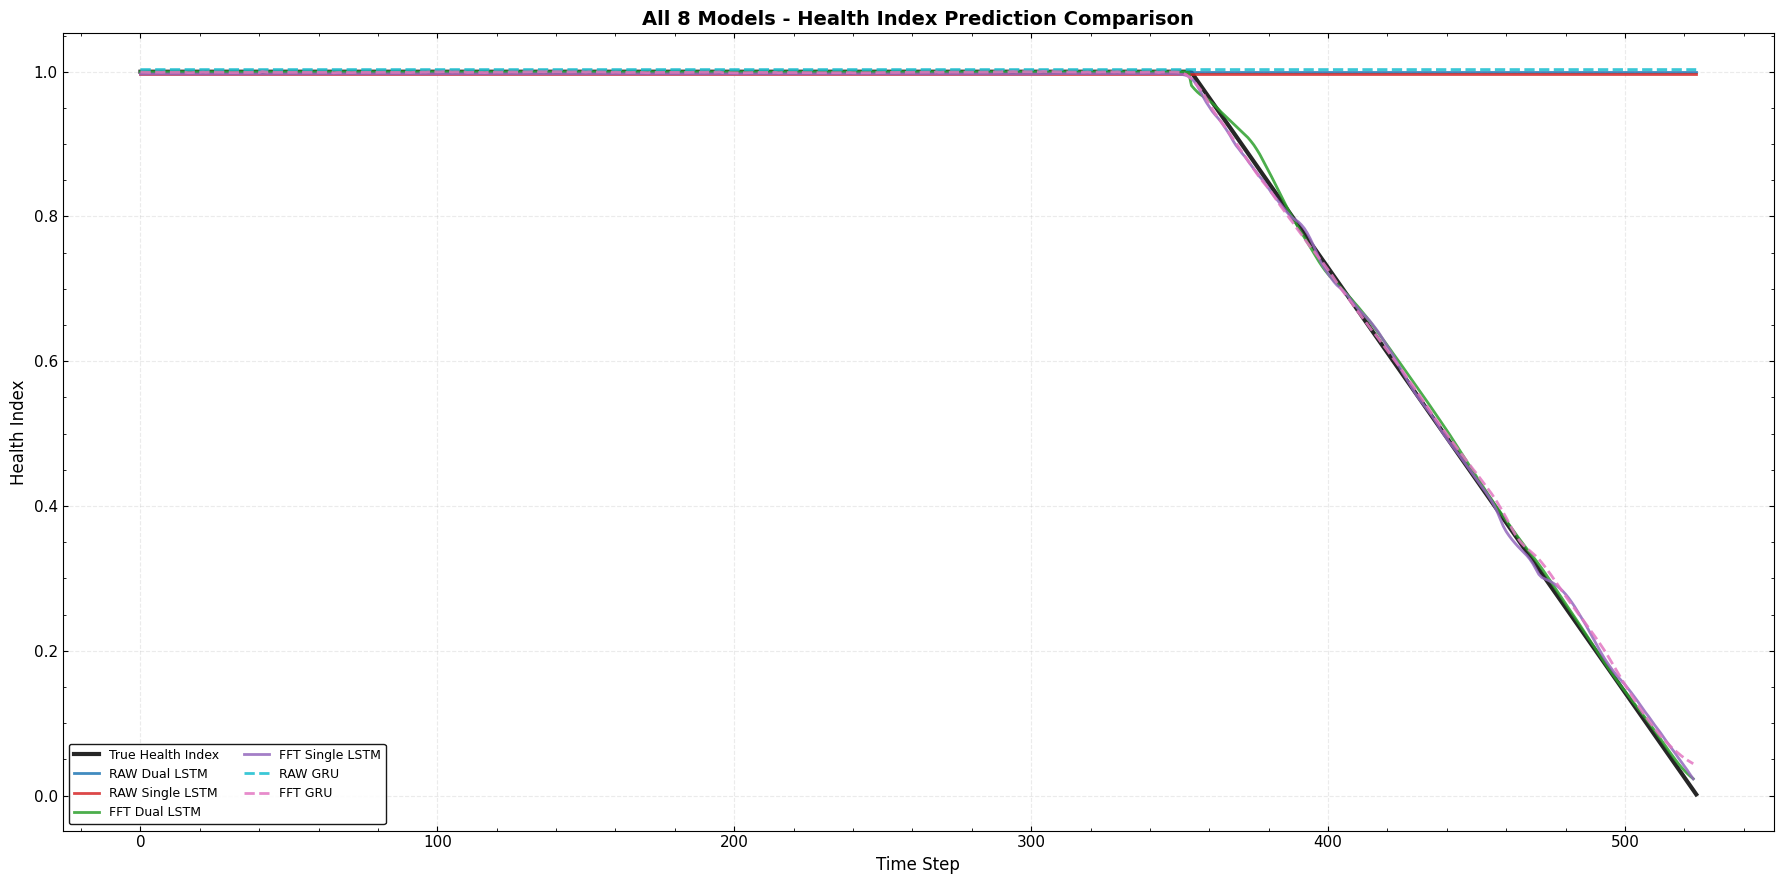

In [39]:
plt.figure(figsize=(18, 9))

# Plot true HI (all models share same ground truth series)
ref_df = prediction_results[MODEL_CONFIGS[0]['name']]
plt.plot(ref_df['time_step'], ref_df['true_health_index'],
         label='True Health Index', color='black', linewidth=3, alpha=0.85)

# Plot all model predictions
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    df = prediction_results[model_name]
    plt.plot(df['time_step'], df['predicted_health_index'],
             label=model_name,
             linewidth=2,
             linestyle=MODEL_STYLES[model_name]['linestyle'],
             color=MODEL_STYLES[model_name]['color'],
             alpha=0.85)

plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Health Index', fontsize=12)
plt.title('All 8 Models - Health Index Prediction Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=9, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. RUL Prediction Visualization

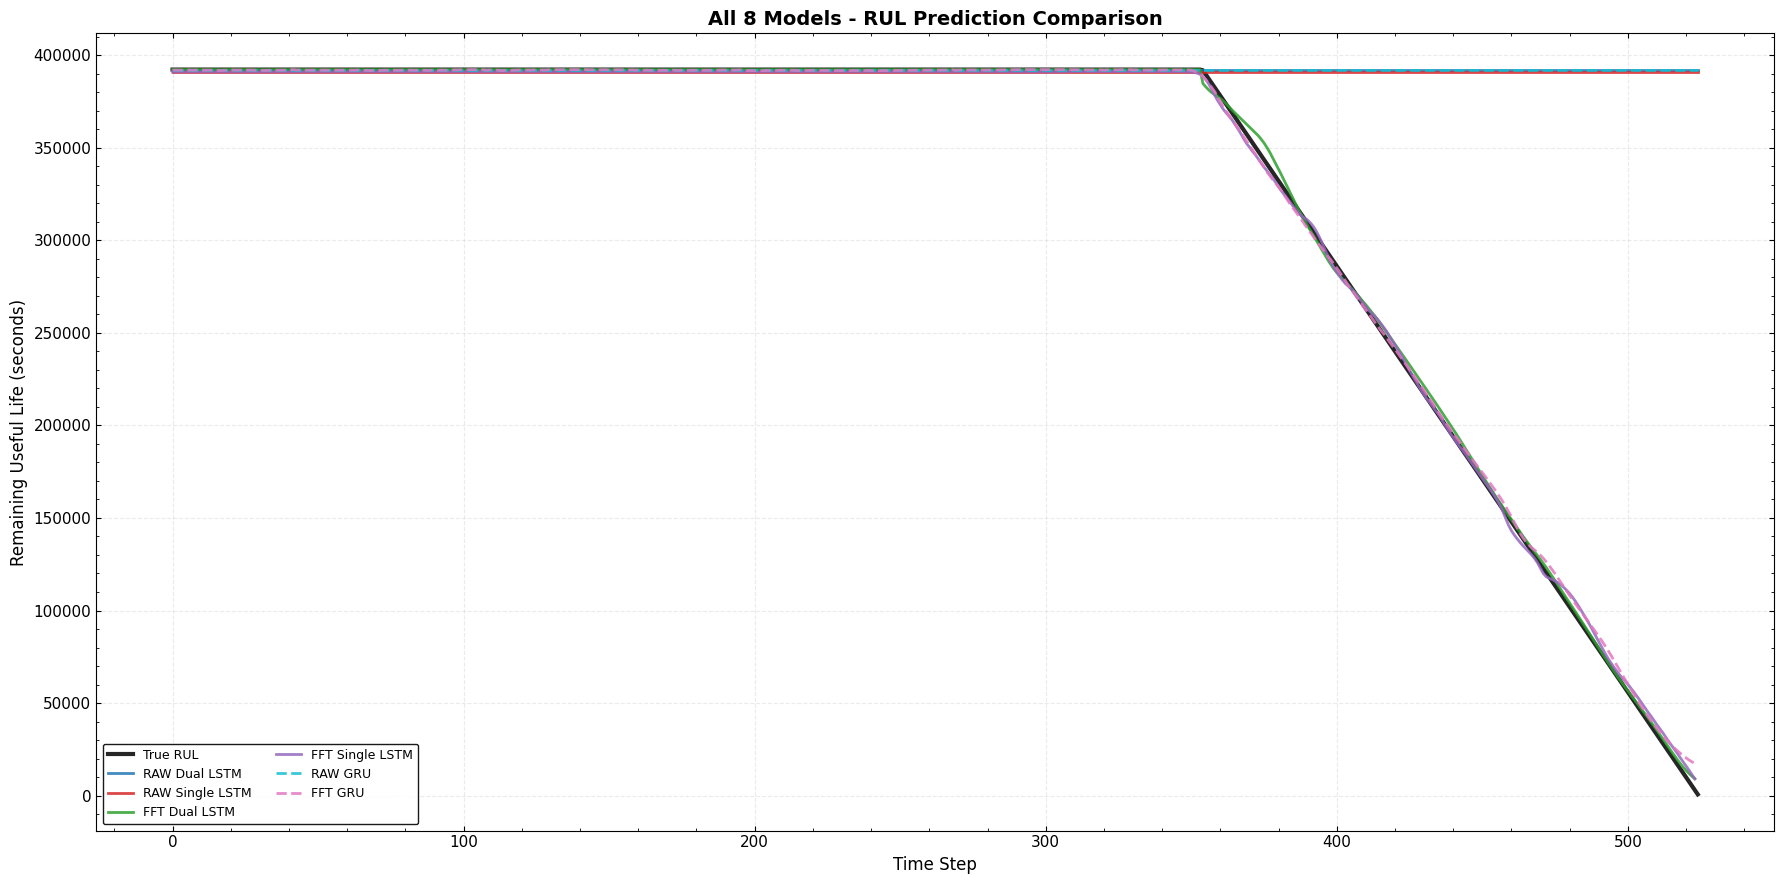

In [40]:
plt.figure(figsize=(18, 9))

# True RUL from reference model
ref_df = prediction_results[MODEL_CONFIGS[0]['name']]
true_rul = ref_df['true_health_index'] * BEARING_LIFESPAN_TIME
plt.plot(ref_df['time_step'], true_rul,
         label='True RUL', color='black', linewidth=3, alpha=0.85)

# Plot all model RUL predictions
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    df = prediction_results[model_name]
    if 'predicted_rul' in df.columns:
        pred_rul = df['predicted_rul']
    else:
        pred_rul = df['predicted_health_index'] * BEARING_LIFESPAN_TIME
    plt.plot(df['time_step'], pred_rul,
             label=model_name,
             linewidth=2,
             linestyle=MODEL_STYLES[model_name]['linestyle'],
             color=MODEL_STYLES[model_name]['color'],
             alpha=0.85)

plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Remaining Useful Life (seconds)', fontsize=12)
plt.title('All 8 Models - RUL Prediction Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=9, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Prediction Error Analysis

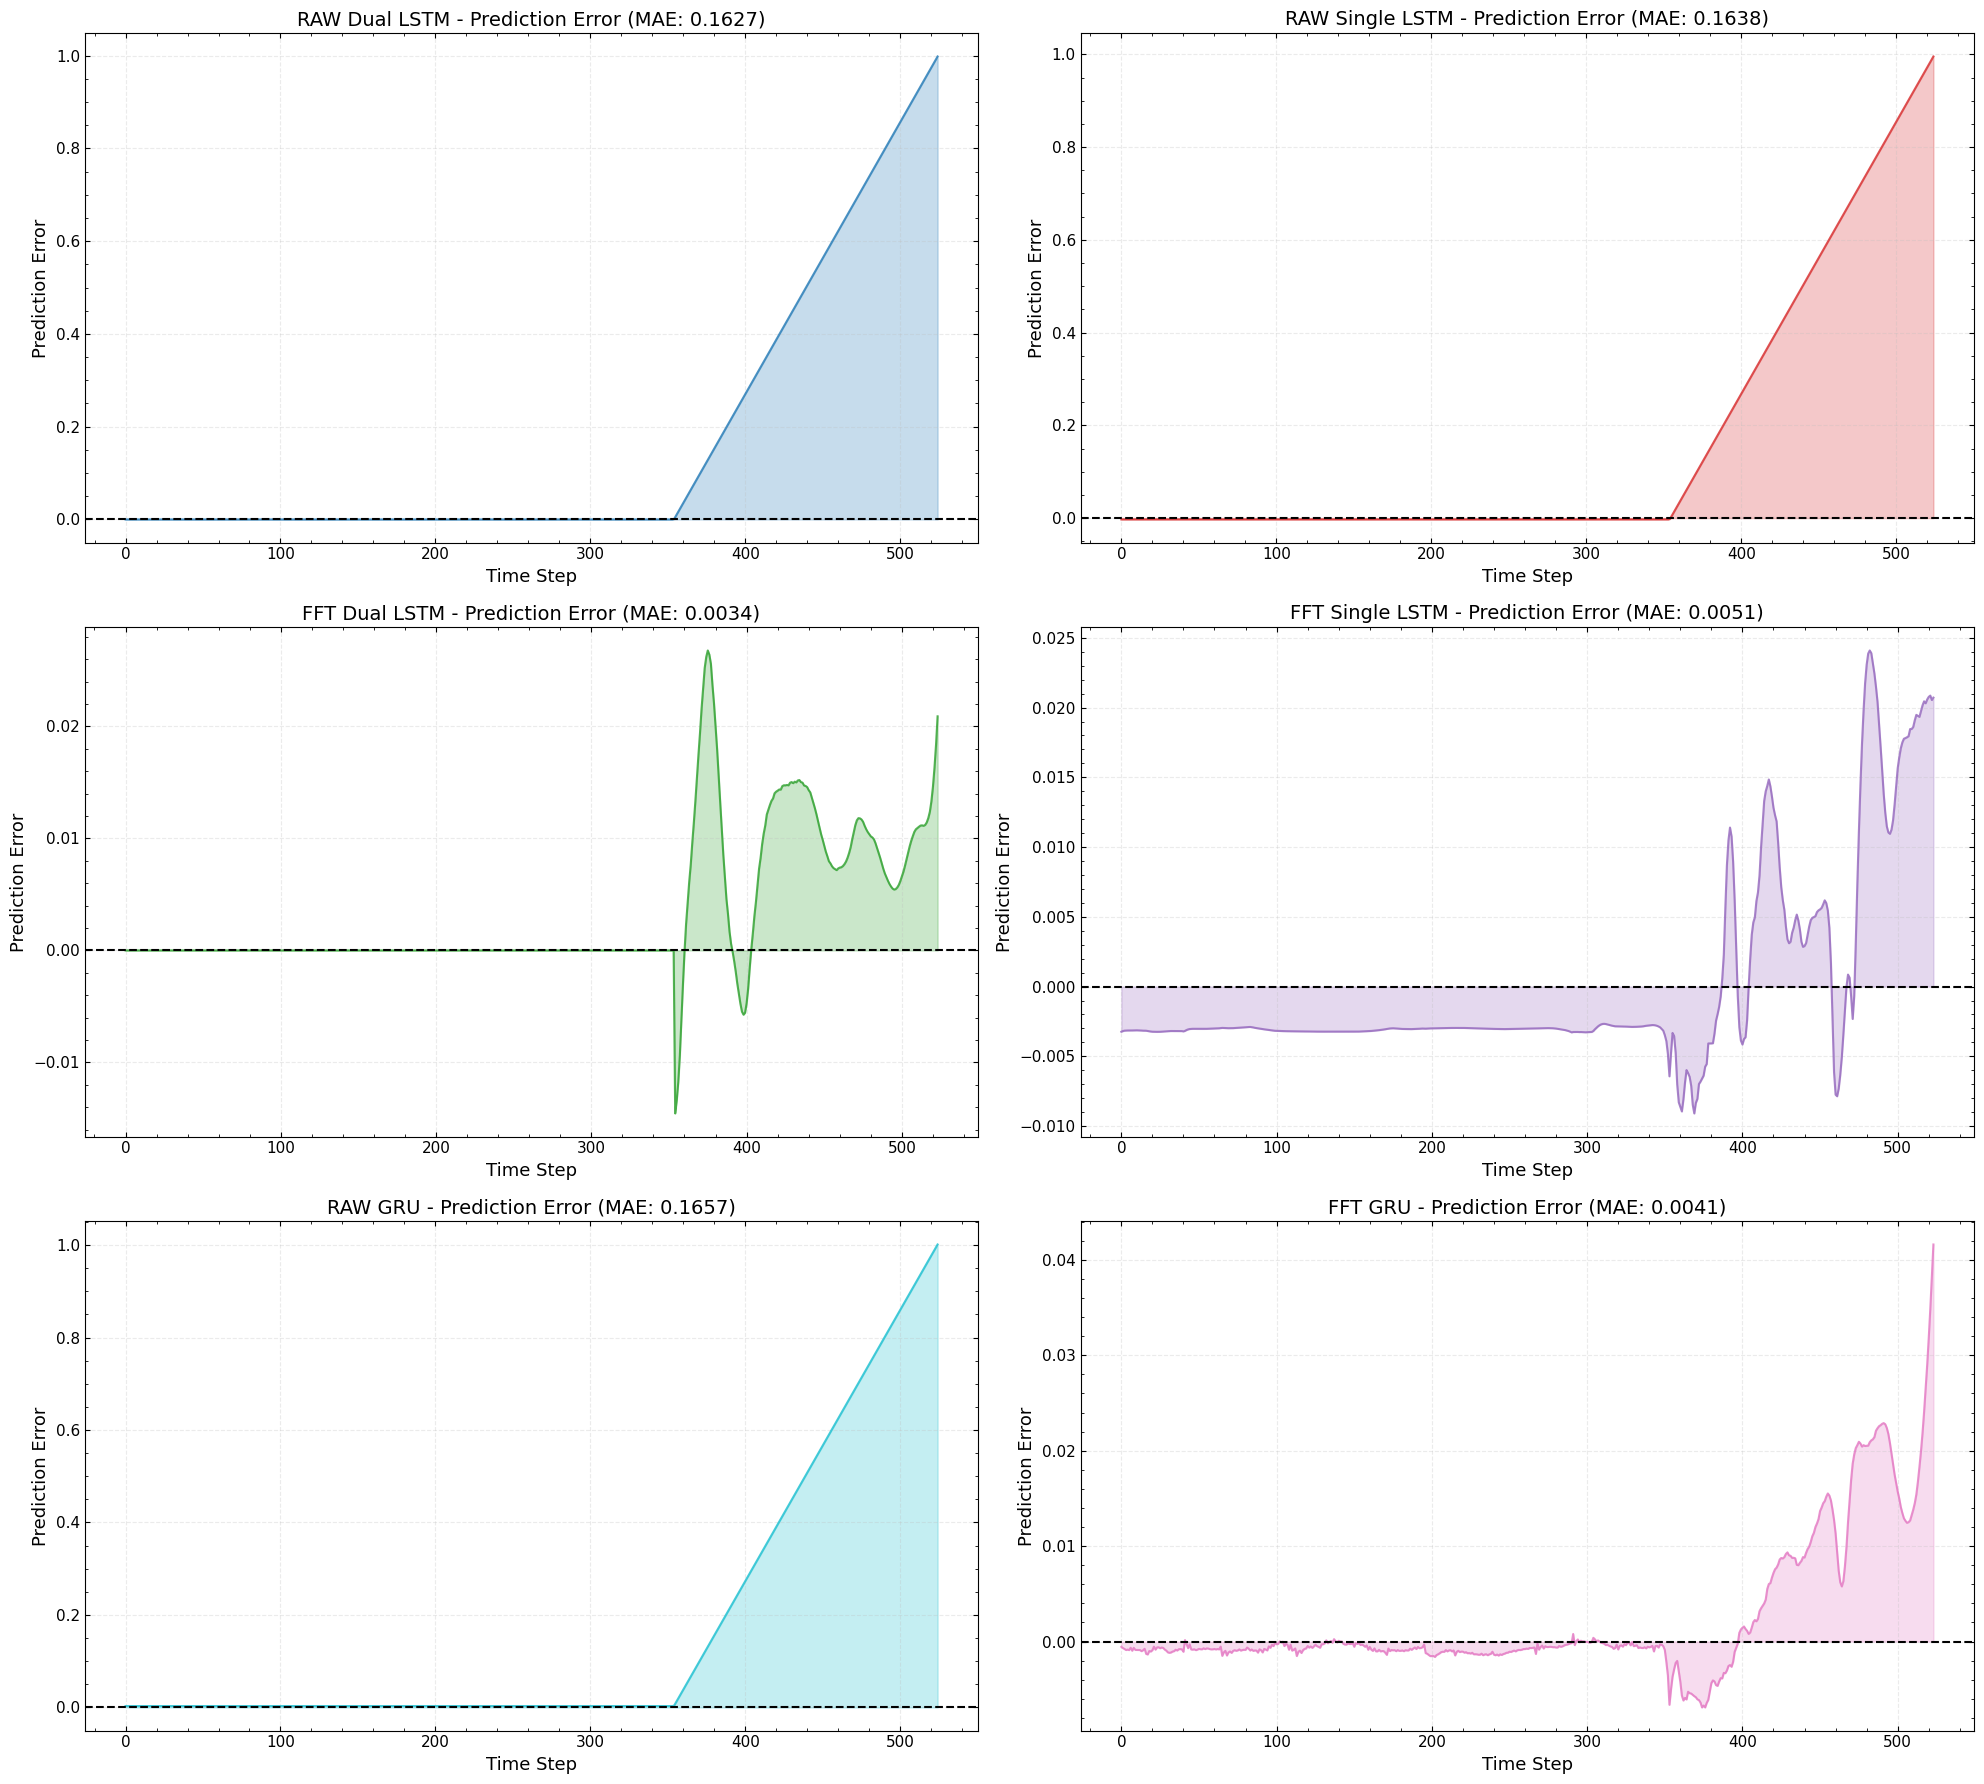

In [41]:
# Prediction error visualization for all 8 models
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
axes = axes.flatten()

metrics_map = test_comparison.set_index('Model').to_dict(orient='index')

for idx, cfg in enumerate(MODEL_CONFIGS):
    model_name = cfg['name']
    df = prediction_results[model_name]
    error = df['predicted_health_index'] - df['true_health_index']
    ax = axes[idx]
    ax.plot(df['time_step'], error,
            color=MODEL_STYLES[model_name]['color'],
            linewidth=1.5, alpha=0.8)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
    ax.fill_between(df['time_step'], error, 0, alpha=0.25,
                    color=MODEL_STYLES[model_name]['color'])
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Prediction Error')
    ax.set_title(f"{model_name} - Prediction Error (MAE: {metrics_map[model_name]['MAE']:.4f})")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Final Ranking and Recommendation

In [42]:
# Calculate absolute errors for each model (8 experiments)
error_dict = {}
max_error_index = {}
base_time_step = prediction_results[MODEL_CONFIGS[0]['name']]['time_step'].values

# Build common time axis across all models (only time steps existing in every model)
common_time_steps = None
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    steps = set(prediction_results[model_name]['time_step'].values)
    common_time_steps = steps if common_time_steps is None else (common_time_steps & steps)

common_time_steps = np.array(sorted(common_time_steps))
error_stats = pd.DataFrame({'Time_Step': common_time_steps})

error_dict = {}
max_error_index = {}

for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    key = model_name.replace(' ', '_')
    df = prediction_results[model_name].copy()

    # Keep original full-series error for diagnostics/marker
    full_abs_error = np.abs(df['predicted_health_index'] - df['true_health_index'])
    error_dict[key] = full_abs_error
    max_error_index[key] = full_abs_error.idxmax()

    # Align to common time axis
    aligned = (
        df.set_index('time_step')
          .reindex(common_time_steps)
    )
    aligned_abs_error = np.abs(aligned['predicted_health_index'] - aligned['true_health_index'])

    error_col = f"{key}_Error"
    cum_col = f"{key}_Cumulative"
    error_stats[error_col] = aligned_abs_error.values
    error_stats[cum_col] = error_stats[error_col].fillna(0).cumsum()

print("="*100)
print("ERROR STATISTICS BY MODEL")
print("="*100)
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    key = model_name.replace(' ', '_')
    abs_error = error_dict[key]
    max_idx = max_error_index[key]
    df = prediction_results[model_name]
    print(f"{model_name}:")
    print(f"  Max Error: {abs_error.max():.6f} at Time Step {df.loc[max_idx, 'time_step']}")
    print(f"  Mean Error: {abs_error.mean():.6f}")
    print(f"  Std Error: {abs_error.std():.6f}")
    print()
print("="*100)

ERROR STATISTICS BY MODEL
RAW Dual LSTM:
  Max Error: 0.998279 at Time Step 524
  Mean Error: 0.162736
  Std Error: 0.286872

RAW Single LSTM:
  Max Error: 0.995383 at Time Step 524
  Mean Error: 0.163753
  Std Error: 0.284652

FFT Dual LSTM:
  Max Error: 0.026769 at Time Step 375
  Mean Error: 0.003434
  Std Error: 0.005827

FFT Single LSTM:
  Max Error: 0.024092 at Time Step 482
  Mean Error: 0.005084
  Std Error: 0.004735

RAW GRU:
  Max Error: 1.001246 at Time Step 524
  Mean Error: 0.165703
  Std Error: 0.286872

FFT GRU:
  Max Error: 0.041607 at Time Step 523
  Mean Error: 0.004084
  Std Error: 0.006607



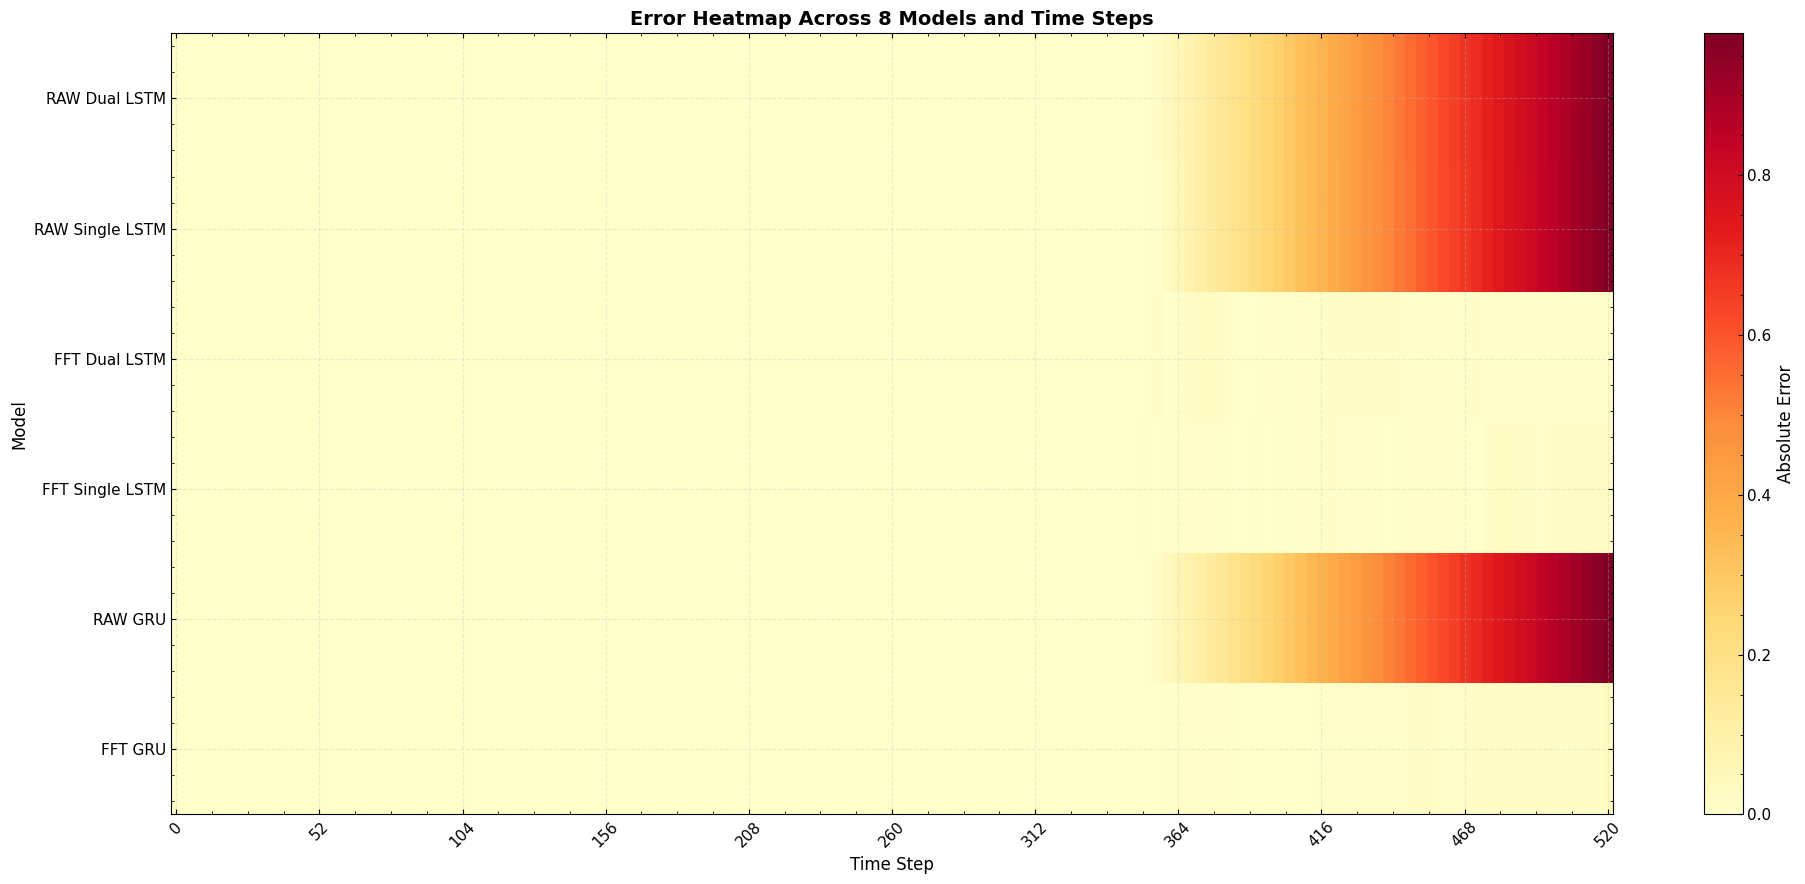


Heatmap shows downsampled error visualization (every 4 time steps)


In [43]:
# Heatmap visualization of errors across models and time (8 models)
fig, ax = plt.subplots(figsize=(20, 9))

model_names = [cfg['name'] for cfg in MODEL_CONFIGS]
model_keys = [name.replace(' ', '_') for name in model_names]

# Create error matrix (models x time_steps)
error_matrix = np.array([
    error_stats[f"{key}_Error"].values for key in model_keys
])

# Downsample for visualization if too many time steps
downsample_factor = max(1, len(error_stats) // 120)
error_matrix_downsampled = error_matrix[:, ::downsample_factor]
time_steps_downsampled = error_stats['Time_Step'].values[::downsample_factor]

im = ax.imshow(error_matrix_downsampled, aspect='auto', cmap='YlOrRd', interpolation='nearest')

ax.set_yticks(np.arange(len(model_names)))
ax.set_yticklabels(model_names)
ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Model', fontsize=12)
ax.set_title('Error Heatmap Across 8 Models and Time Steps', fontsize=14, fontweight='bold')

# Show subset of time step labels
num_labels = 10
step = max(1, len(time_steps_downsampled) // num_labels)
xtick_positions = np.arange(0, len(time_steps_downsampled), step)
xtick_labels = [int(time_steps_downsampled[i]) for i in xtick_positions]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=45)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Absolute Error', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nHeatmap shows downsampled error visualization (every {downsample_factor} time steps)")

In [44]:
# Identify high-error regions (where error > threshold)
error_threshold = 0.1  # 10% error threshold

high_error_regions = {}
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    key = model_name.replace(' ', '_')
    error_col = f"{key}_Error"
    high_errors = error_stats[error_col] > error_threshold
    high_error_count = int(high_errors.sum())
    high_error_percentage = (high_error_count / len(error_stats)) * 100

    # Find start and end of high-error regions
    regions = []
    in_region = False
    start_idx = None

    for idx, is_high in enumerate(high_errors):
        if is_high and not in_region:
            start_idx = idx
            in_region = True
        elif (not is_high) and in_region:
            regions.append((error_stats.loc[start_idx, 'Time_Step'],
                            error_stats.loc[idx - 1, 'Time_Step']))
            in_region = False

    if in_region:
        regions.append((error_stats.loc[start_idx, 'Time_Step'],
                        error_stats.loc[len(error_stats) - 1, 'Time_Step']))

    high_error_regions[model_name] = {
        'count': high_error_count,
        'percentage': high_error_percentage,
        'regions': regions[:5]
    }

print("\n" + "="*100)
print(f"HIGH-ERROR REGIONS (Error > {error_threshold:.2f})")
print("="*100)
for model_name, stats in high_error_regions.items():
    print(f"\n{model_name}:")
    print(f"  High-error time steps: {stats['count']} ({stats['percentage']:.2f}%)")
    if stats['regions']:
        print(f"  First {len(stats['regions'])} high-error regions:")
        for i, (start, end) in enumerate(stats['regions'], 1):
            print(f"    {i}. Time Step {start} to {end}")
    else:
        print("  No high-error regions found")
print("="*100)


HIGH-ERROR REGIONS (Error > 0.10)

RAW Dual LSTM:
  High-error time steps: 153 (29.20%)
  First 1 high-error regions:
    1. Time Step 371 to 523

RAW Single LSTM:
  High-error time steps: 152 (29.01%)
  First 1 high-error regions:
    1. Time Step 372 to 523

FFT Dual LSTM:
  High-error time steps: 0 (0.00%)
  No high-error regions found

FFT Single LSTM:
  High-error time steps: 0 (0.00%)
  No high-error regions found

RAW GRU:
  High-error time steps: 153 (29.20%)
  First 1 high-error regions:
    1. Time Step 371 to 523

FFT GRU:
  High-error time steps: 0 (0.00%)
  No high-error regions found



ERROR DISTRIBUTION BY TIME PERIOD
          Model  Early Period (0-33%)  Middle Period (33-66%)  Late Period (66-100%)
  RAW Dual LSTM              0.000000                0.000000               0.482504
RAW Single LSTM              0.002896                0.002896               0.479795
  FFT Dual LSTM              0.000000                0.000000               0.010282
FFT Single LSTM              0.003132                0.002990               0.009118
        RAW GRU              0.002967                0.002967               0.485471
        FFT GRU              0.000705                0.000764               0.010765


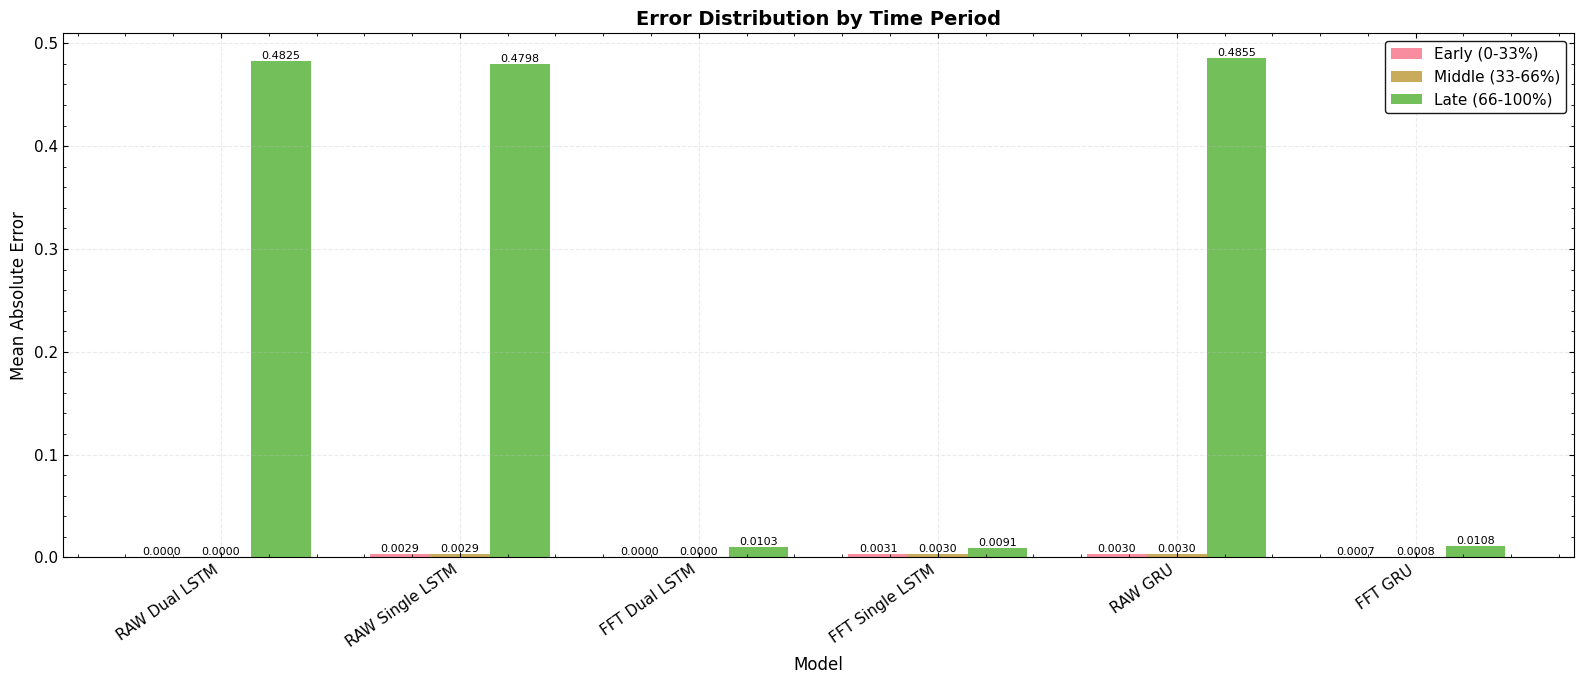

In [45]:
# Analyze error distribution by time periods (early, middle, late)
total_steps = len(error_stats)
early_period = total_steps // 3
middle_period = 2 * total_steps // 3

# Calculate error statistics for each period
period_stats = []
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    key = model_name.replace(' ', '_')
    error_col = f"{key}_Error"

    early_error = error_stats[error_col][:early_period].mean()
    middle_error = error_stats[error_col][early_period:middle_period].mean()
    late_error = error_stats[error_col][middle_period:].mean()

    period_stats.append({
        'Model': model_name,
        'Early Period (0-33%)': early_error,
        'Middle Period (33-66%)': middle_error,
        'Late Period (66-100%)': late_error
    })

period_comparison = pd.DataFrame(period_stats)

print("\n" + "="*100)
print("ERROR DISTRIBUTION BY TIME PERIOD")
print("="*100)
print(period_comparison.to_string(index=False))
print("="*100)

# Visualize error by period
fig, ax = plt.subplots(figsize=(16, 7))

x_pos = np.arange(len(period_comparison))
width = 0.25

bars1 = ax.bar(x_pos - width, period_comparison['Early Period (0-33%)'],
               width, label='Early (0-33%)', alpha=0.8)
bars2 = ax.bar(x_pos, period_comparison['Middle Period (33-66%)'],
               width, label='Middle (33-66%)', alpha=0.8)
bars3 = ax.bar(x_pos + width, period_comparison['Late Period (66-100%)'],
               width, label='Late (66-100%)', alpha=0.8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Mean Absolute Error', fontsize=12)
ax.set_title('Error Distribution by Time Period', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(period_comparison['Model'], rotation=35, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

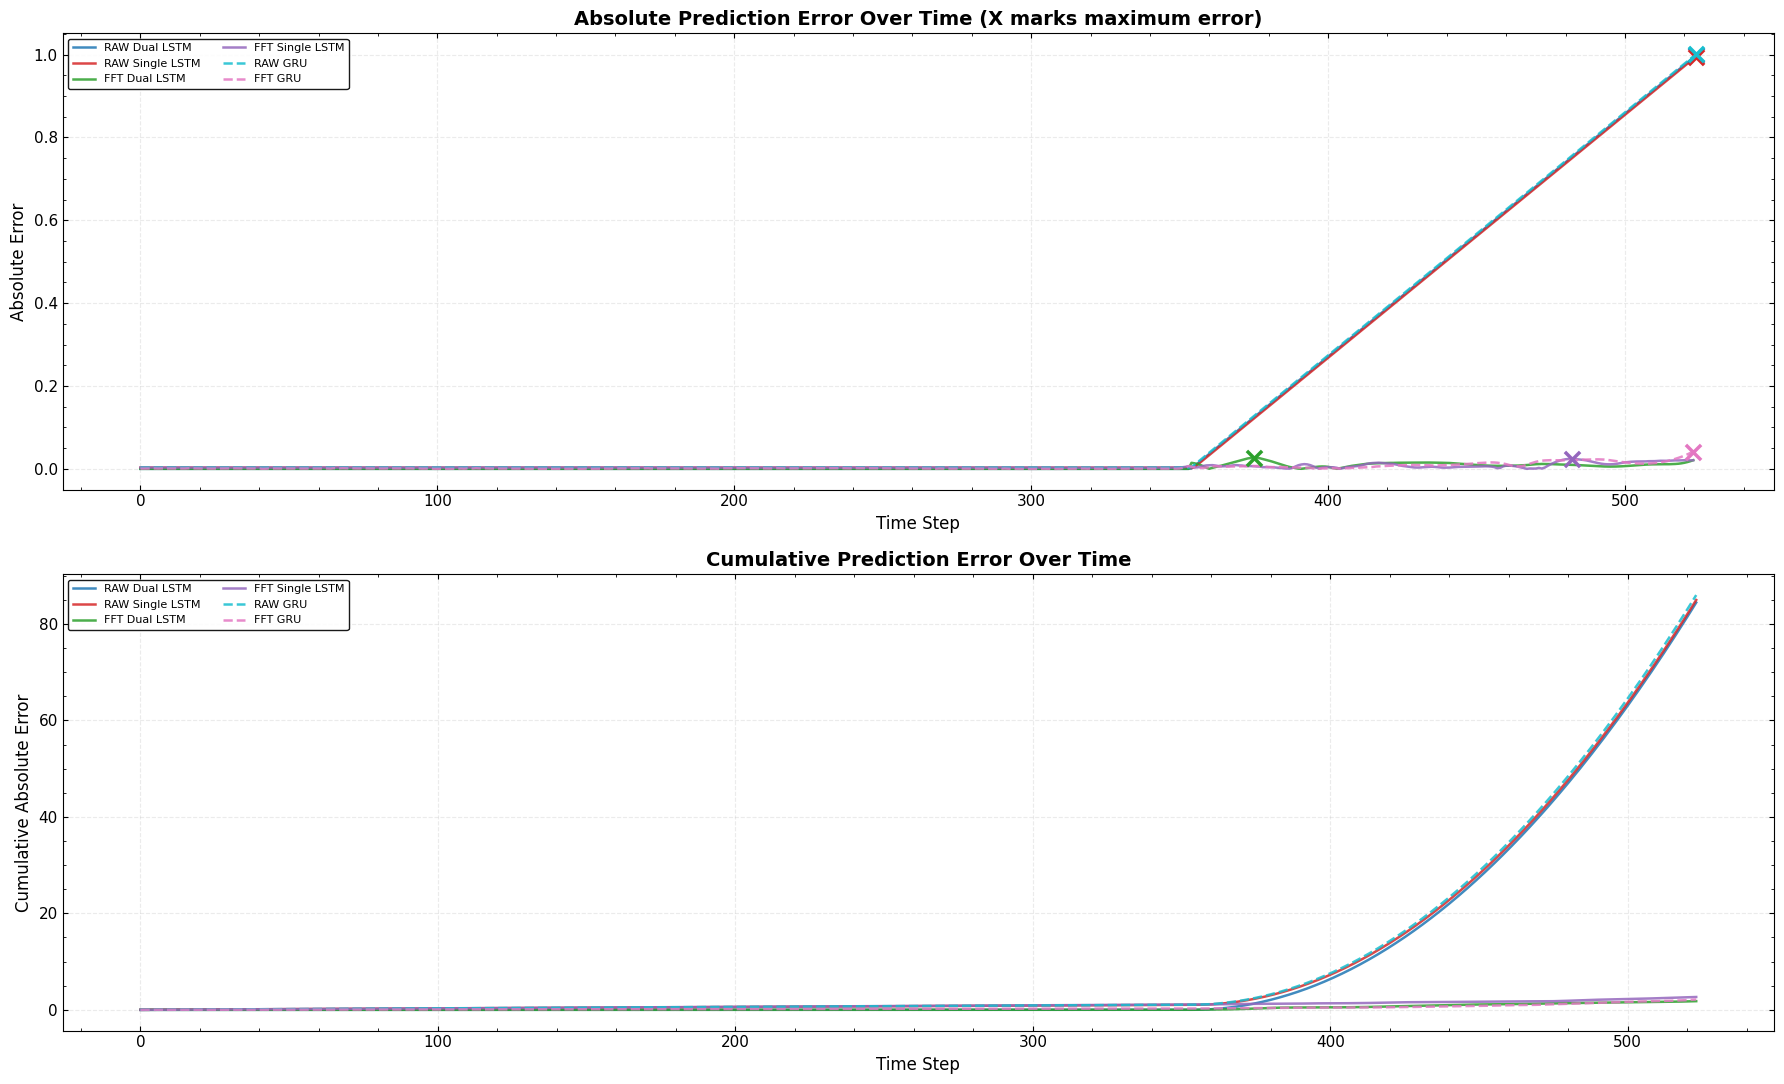

In [46]:
# Plot absolute and cumulative error over time for all 8 models
fig, axes = plt.subplots(2, 1, figsize=(18, 11))

# Absolute Error Over Time
ax = axes[0]
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    key = model_name.replace(' ', '_')
    ax.plot(error_stats['Time_Step'], error_stats[f"{key}_Error"],
            label=model_name,
            linewidth=1.8, alpha=0.85,
            color=MODEL_STYLES[model_name]['color'],
            linestyle=MODEL_STYLES[model_name]['linestyle'])

    # Mark maximum error point
    df = prediction_results[model_name]
    max_idx = max_error_index[key]
    max_x = df.loc[max_idx, 'time_step']
    max_y = error_dict[key].max()
    ax.scatter(max_x, max_y,
               color=MODEL_STYLES[model_name]['color'],
               s=120, marker='x', linewidths=2.5, zorder=5)

ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Absolute Error', fontsize=12)
ax.set_title('Absolute Prediction Error Over Time (X marks maximum error)', fontsize=14, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Cumulative Error Over Time
ax = axes[1]
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    key = model_name.replace(' ', '_')
    ax.plot(error_stats['Time_Step'], error_stats[f"{key}_Cumulative"],
            label=model_name,
            linewidth=1.8, alpha=0.85,
            color=MODEL_STYLES[model_name]['color'],
            linestyle=MODEL_STYLES[model_name]['linestyle'])

ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Cumulative Absolute Error', fontsize=12)
ax.set_title('Cumulative Prediction Error Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Error Metrics by Time Step

In [47]:
# Rank models based on different metrics (including asymmetric loss)
ranking_df = test_comparison.copy()

# Add rankings (1 = best)
ranking_df['RMSE_Rank'] = ranking_df['RMSE'].rank()
ranking_df['MAE_Rank'] = ranking_df['MAE'].rank()
ranking_df['R²_Rank'] = ranking_df['R²'].rank(ascending=False)  # Higher is better
ranking_df['RPE_Rank'] = ranking_df['RPE (%)'].rank()

# Include Asymmetric Loss rank if available
if 'Asymmetric Loss' in ranking_df.columns and ranking_df['Asymmetric Loss'].notna().any():
    ranking_df['Asym_Rank'] = ranking_df['Asymmetric Loss'].rank()
    ranking_df['Average_Rank'] = (
        ranking_df['RMSE_Rank'] +
        ranking_df['MAE_Rank'] +
        ranking_df['R²_Rank'] +
        ranking_df['RPE_Rank'] +
        ranking_df['Asym_Rank']
    ) / 5
else:
    ranking_df['Average_Rank'] = (
        ranking_df['RMSE_Rank'] +
        ranking_df['MAE_Rank'] +
        ranking_df['R²_Rank'] +
        ranking_df['RPE_Rank']
    ) / 4

# Sort by average rank
ranking_df = ranking_df.sort_values('Average_Rank')

print("\n" + "="*100)
print(f"MODEL RANKING (1 = Best, {len(ranking_df)} = Worst)")
print("="*100)
cols_to_show = ['Model', 'RMSE_Rank', 'MAE_Rank', 'R²_Rank', 'RPE_Rank']
if 'Asym_Rank' in ranking_df.columns:
    cols_to_show.append('Asym_Rank')
cols_to_show.append('Average_Rank')
print(ranking_df[cols_to_show].to_string(index=False))
print("="*100)

# Best model
best_model = ranking_df.iloc[0]['Model']
print(f"\nBest Overall Model: {best_model}")
print(f"  Average Rank: {ranking_df.iloc[0]['Average_Rank']:.2f}")
print(f"  RMSE: {ranking_df.iloc[0]['RMSE']:.4f}")
print(f"  MAE: {ranking_df.iloc[0]['MAE']:.4f}")
print(f"  R²: {ranking_df.iloc[0]['R²']:.4f}")
print(f"  RPE: {ranking_df.iloc[0]['RPE (%)']:.2f}%")
if 'Asymmetric Loss' in ranking_df.columns:
    print(f"  Asymmetric Loss: {ranking_df.iloc[0]['Asymmetric Loss']:.4f}")

print("\n" + "="*100)
print("RECOMMENDATIONS")
print("="*100)
print("Based on the comprehensive analysis:")
for rank, (_, row) in enumerate(ranking_df.iterrows(), start=1):
    print(f"{rank}. {row['Model']} (Average Rank: {row['Average_Rank']:.2f})")
print("="*100)


MODEL RANKING (1 = Best, 6 = Worst)
          Model  RMSE_Rank  MAE_Rank  R²_Rank  RPE_Rank  Asym_Rank  Average_Rank
  FFT Dual LSTM        1.0       1.0      1.0       1.0        1.0           1.0
FFT Single LSTM        2.0       3.0      2.0       2.0        3.0           2.4
        FFT GRU        3.0       2.0      3.0       3.0        2.0           2.6
RAW Single LSTM        4.0       5.0      4.0       4.0        5.0           4.4
  RAW Dual LSTM        5.0       4.0      5.0       5.0        4.0           4.6
        RAW GRU        6.0       6.0      6.0       6.0        6.0           6.0

Best Overall Model: FFT Dual LSTM
  Average Rank: 1.00
  RMSE: 0.0068
  MAE: 0.0034
  R²: 0.9994
  RPE: 3.70%
  Asymmetric Loss: 0.0003

RECOMMENDATIONS
Based on the comprehensive analysis:
1. FFT Dual LSTM (Average Rank: 1.00)
2. FFT Single LSTM (Average Rank: 2.40)
3. FFT GRU (Average Rank: 2.60)
4. RAW Single LSTM (Average Rank: 4.40)
5. RAW Dual LSTM (Average Rank: 4.60)
6. RAW GRU (Avera

## 7. Export Summary Report

In [48]:
# Create a comprehensive summary report
summary_report = pd.DataFrame({
    'Model': test_comparison['Model'],
    'Training_Epochs': training_summary['Total Epochs'],
    'Final_HI_Loss': training_summary['Final HI Loss'],
    'Best_HI_Loss': training_summary['Best HI Loss'],
    'Test_RMSE': test_comparison['RMSE'],
    'Test_MAE': test_comparison['MAE'],
    'Test_R²': test_comparison['R²'],
    'Test_RPE(%)': test_comparison['RPE (%)'],
    'Test_Asymmetric_Loss': test_comparison.get('Asymmetric Loss', pd.Series([np.nan]*len(test_comparison))),
})

# Save to CSV
output_path = f"{DATASET_PATH}/model_comparison_summary.csv"
summary_report.to_csv(output_path, index=False)
print(f"\n✅ Summary report saved to: {output_path}")

print("\n" + "="*80)
print("COMPLETE SUMMARY REPORT")
print("="*80)
print(summary_report.to_string(index=False))
print("="*80)


✅ Summary report saved to: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/model_comparison_summary.csv

COMPLETE SUMMARY REPORT
          Model  Training_Epochs  Final_HI_Loss  Best_HI_Loss  Test_RMSE  Test_MAE   Test_R²  Test_RPE(%)  Test_Asymmetric_Loss
  RAW Dual LSTM              400       0.022288      0.021440   0.329578  0.162736 -0.322419   250.759941              0.012846
RAW Single LSTM              389       0.012876      0.012746   0.328158  0.163753 -0.311043   250.135310              0.012966
  FFT Dual LSTM              400       0.001779      0.001550   0.006759  0.003434  0.999443     3.698374              0.000269
FFT Single LSTM              400       0.000959      0.000868   0.006945  0.005084  0.999412     4.534399              0.000451
        RAW GRU              400       0.012831      0.012748   0.331053  0.165703 -0.334282   251.800599              0.013077
        FFT GRU              400       0.001013      0.000729   0.007

In [49]:
# 8. Metrics vs Cycle Time Before Failure (Tail Performance)
from tqdm import tqdm

# Config: stability and clipping
MIN_TAIL_LEN = 10      # skip metrics when fewer than this many points remain
RPE_EPS = 1e-6         # clip denominator in RPE to avoid explosions near zero HI

def compute_tail_metrics(df, model_name):
    times = df['time_step'].values
    y_true = df['true_health_index'].values
    y_pred = df['predicted_health_index'].values

    tail_rmse, tail_mae, tail_r2, tail_rpe, tail_asym = [], [], [], [], []
    cycle_time_before_failure = []

    # Iterate forward; tail = i .. end
    for i in range(len(df)):
        y_true_tail = y_true[i:]
        y_pred_tail = y_pred[i:]

        if len(y_true_tail) < MIN_TAIL_LEN:
            tail_rmse.append(np.nan)
            tail_mae.append(np.nan)
            tail_r2.append(np.nan)
            tail_rpe.append(np.nan)
            tail_asym.append(np.nan)
        else:
            mse = mean_squared_error(y_true_tail, y_pred_tail)
            rmse = float(np.sqrt(mse))
            mae = float(mean_absolute_error(y_true_tail, y_pred_tail))
            try:
                r2 = float(r2_score(y_true_tail, y_pred_tail))
            except Exception:
                r2 = np.nan

            y_true_clip = np.where(np.abs(y_true_tail) < RPE_EPS, RPE_EPS, y_true_tail)
            rpe = float(np.mean(np.abs((y_true_tail - y_pred_tail) / y_true_clip)) * 100)
            asym = float(asymmetric_loss_scoring_function(y_true_tail, y_pred_tail))

            tail_rmse.append(rmse)
            tail_mae.append(mae)
            tail_r2.append(r2)
            tail_rpe.append(rpe)
            tail_asym.append(asym)

        cycle_time_before_failure.append(max(0, BEARING_LIFESPAN_TIME - times[i]))

    return pd.DataFrame({
        'Cycle_Time_Before_Failure': cycle_time_before_failure,
        'RMSE': tail_rmse,
        'MAE': tail_mae,
        'R²': tail_r2,
        'RPE (%)': tail_rpe,
        'Asymmetric Loss': tail_asym,
        'Model': model_name
    })

print("\nComputing tail performance metrics for all 8 models...")

tail_metrics_by_model = {}
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    tail_metrics_by_model[model_name] = compute_tail_metrics(prediction_results[model_name], model_name)

tail_metrics_all = pd.concat([tail_metrics_by_model[m] for m in tail_metrics_by_model], ignore_index=True)

print("Tail metrics computed for all models (NaNs indicate skipped short tails).")
print(tail_metrics_all.head())


Computing tail performance metrics for all 8 models...
Tail metrics computed for all models (NaNs indicate skipped short tails).
   Cycle_Time_Before_Failure      RMSE       MAE        R²     RPE (%)  \
0                     392275  0.329578  0.162736 -0.322419  250.759941   
1                     392274  0.329893  0.163047 -0.323233  251.238490   
2                     392273  0.330208  0.163358 -0.324051  251.718870   
3                     392272  0.330524  0.163671 -0.324873  252.201090   
4                     392271  0.330841  0.163986 -0.325700  252.685161   

   Asymmetric Loss          Model  
0         0.012846  RAW Dual LSTM  
1         0.012870  RAW Dual LSTM  
2         0.012895  RAW Dual LSTM  
3         0.012920  RAW Dual LSTM  
4         0.012944  RAW Dual LSTM  


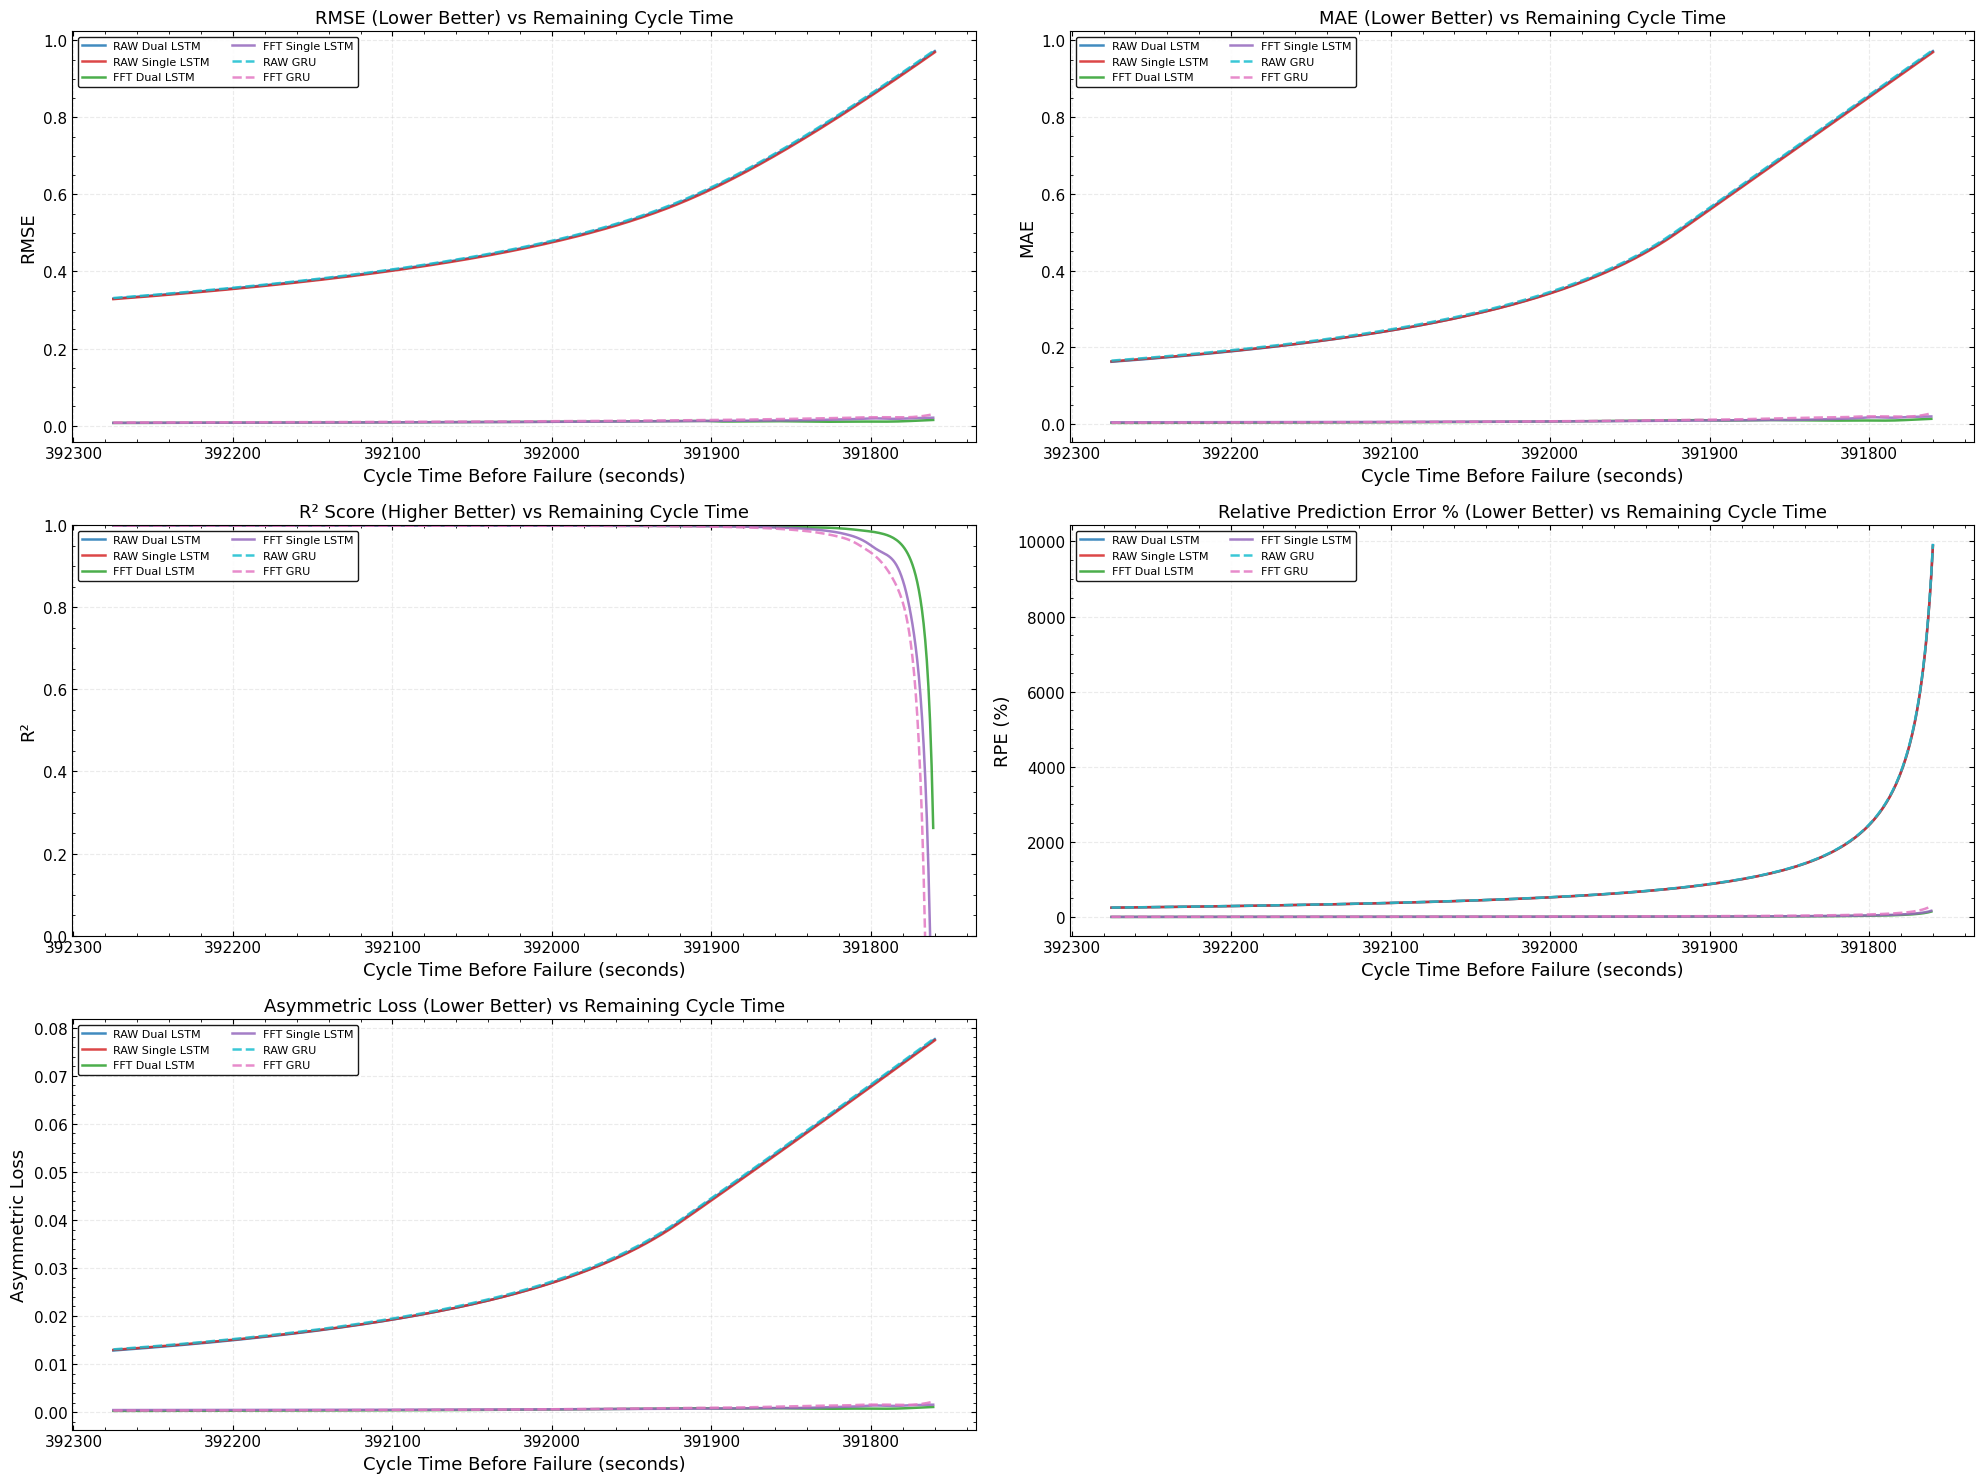


Generated tail metric plots vs remaining cycle time (x-axis inverted).


In [50]:
# Plot: Tail Metrics vs Cycle Time Before Failure (8 models)
# X-axis inverted so failure is on the right

colors_map = {name: MODEL_STYLES[name]['color'] for name in MODEL_STYLES}
linestyle_map = {name: MODEL_STYLES[name]['linestyle'] for name in MODEL_STYLES}

fig, axes = plt.subplots(3, 2, figsize=(20, 15))
metric_list = [
    ('RMSE', 'RMSE (Lower Better)'),
    ('MAE', 'MAE (Lower Better)'),
    ('R²', 'R² Score (Higher Better)'),
    ('RPE (%)', 'Relative Prediction Error % (Lower Better)'),
    ('Asymmetric Loss', 'Asymmetric Loss (Lower Better)')
]

for idx, (metric_key, title) in enumerate(metric_list):
    r = idx // 2
    c = idx % 2
    ax = axes[r, c]
    for cfg in MODEL_CONFIGS:
        model_name = cfg['name']
        dfm = tail_metrics_by_model[model_name]
        ax.plot(
            dfm['Cycle_Time_Before_Failure'],
            dfm[metric_key],
            label=model_name,
            color=colors_map[model_name],
            linestyle=linestyle_map[model_name],
            linewidth=1.8,
            alpha=0.85
        )
    ax.set_title(f'{title} vs Remaining Cycle Time', fontsize=13)
    ax.set_xlabel('Cycle Time Before Failure (seconds)')
    ax.set_ylabel(metric_key)
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()
    if metric_key == 'R²':
        ax.set_ylim([0, 1])
    ax.legend(fontsize=8, ncol=2)

# Hide unused subplot
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

print("\nGenerated tail metric plots vs remaining cycle time (x-axis inverted).")

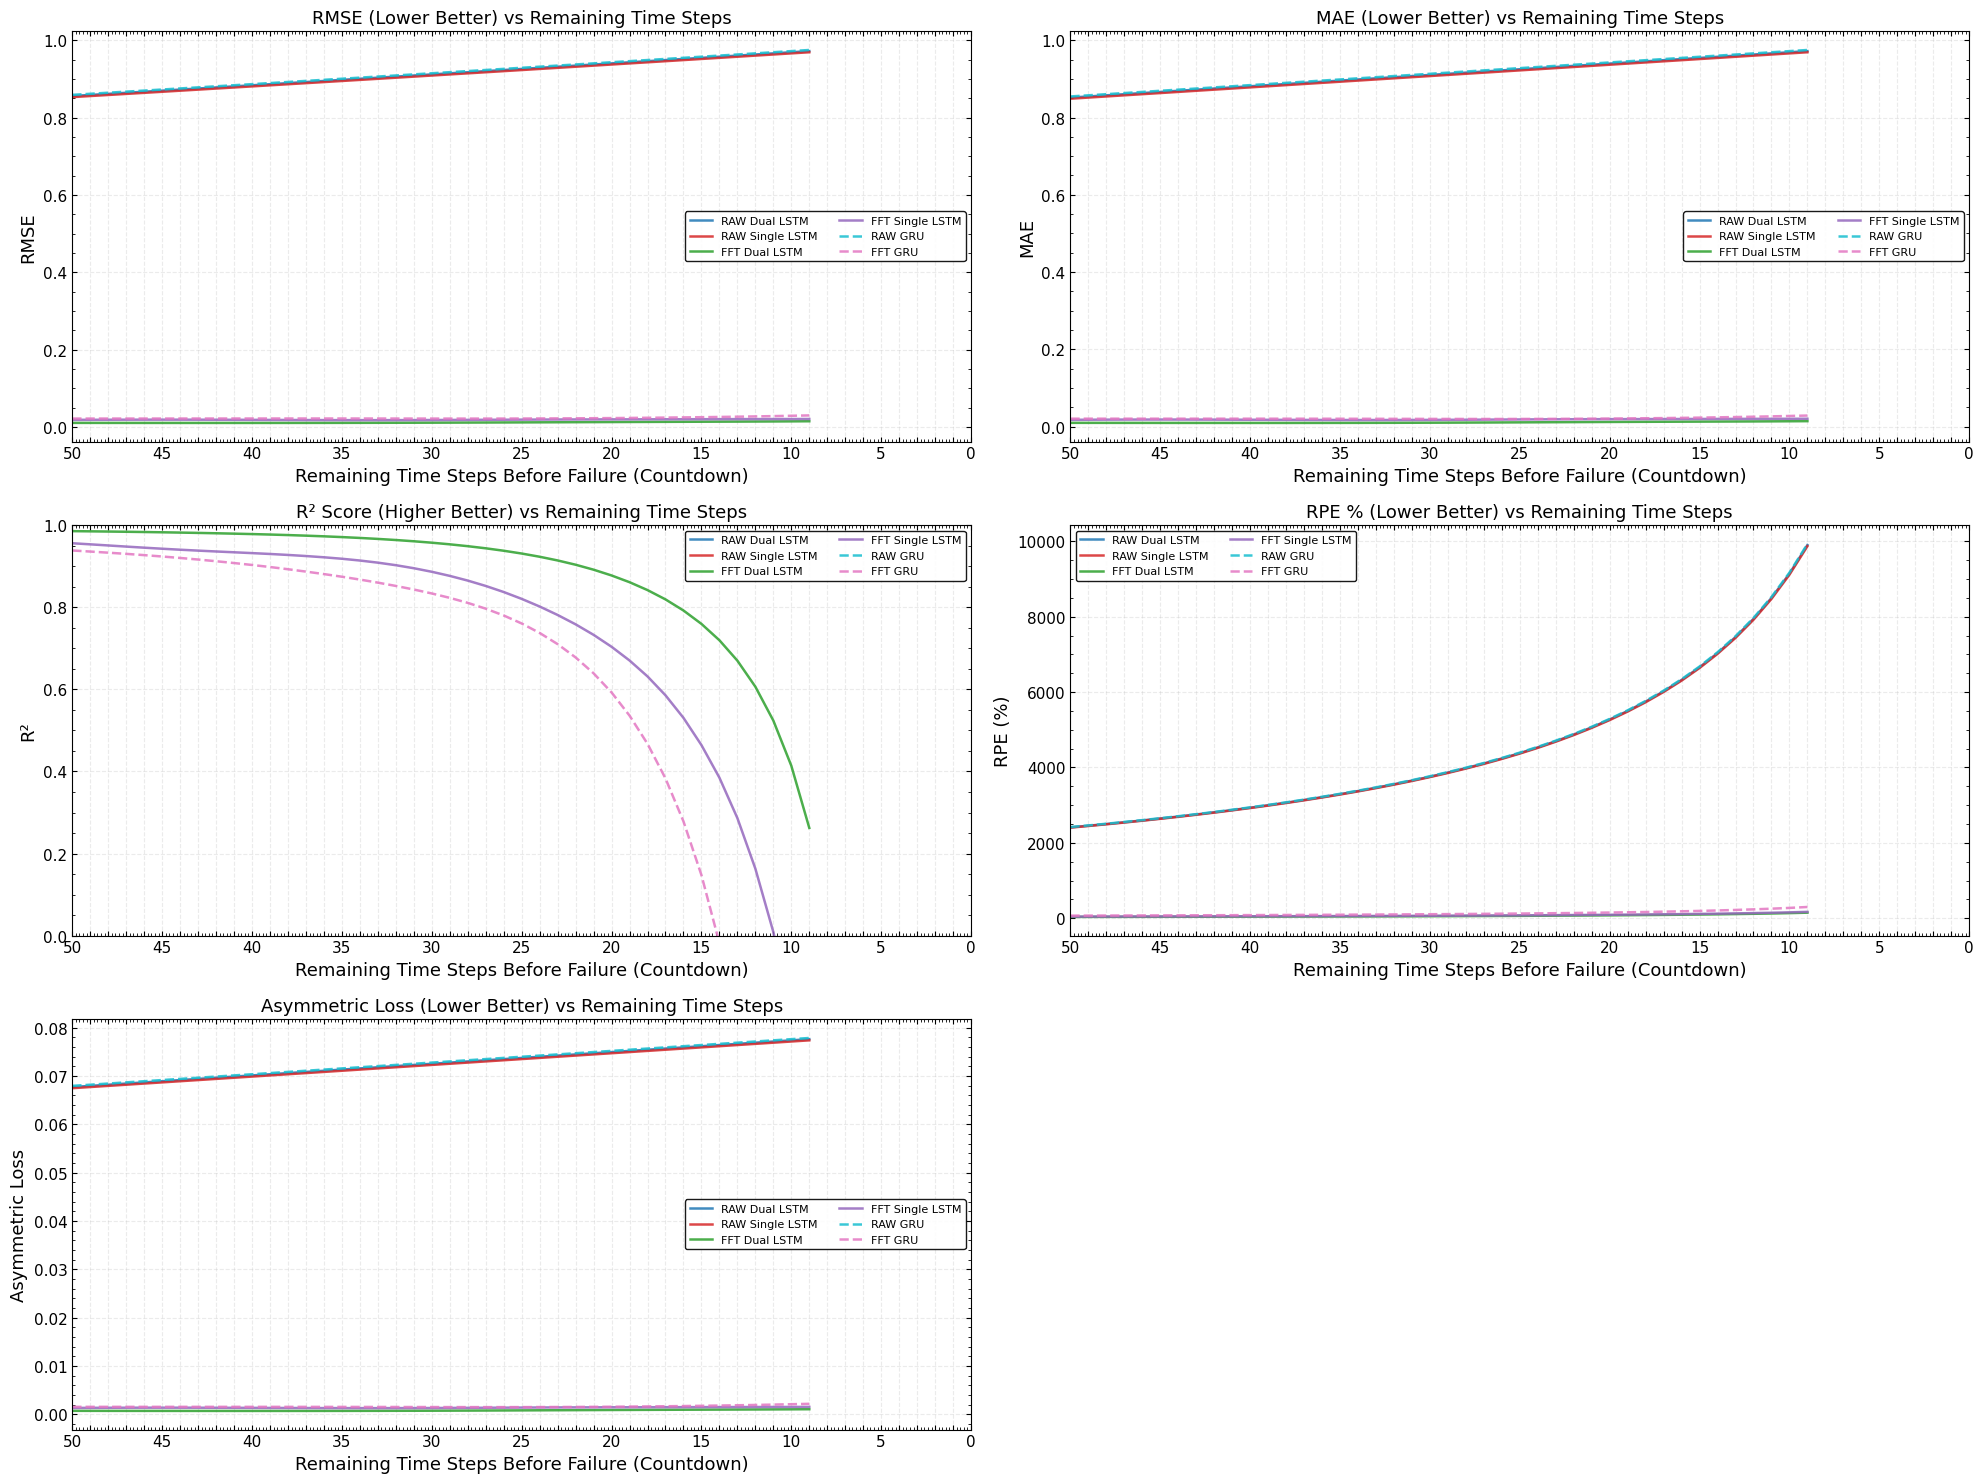


Countdown plots generated for remaining time steps 50..0 (0 = failure).


In [51]:
# Countdown Plots: Metrics vs Remaining Time Steps (50 -> 0, 0 = Failure)

# Attach remaining time steps if not already present
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    tail_df = tail_metrics_by_model[model_name]
    if 'Remaining_Time_Steps' not in tail_df.columns:
        total_len = len(prediction_results[model_name])
        tail_df['Remaining_Time_Steps'] = (total_len - 1) - np.arange(total_len)
        tail_metrics_by_model[model_name] = tail_df

# Limit to last N remaining steps
N = 50
model_tail_subset = {}
for cfg in MODEL_CONFIGS:
    model_name = cfg['name']
    dfm = tail_metrics_by_model[model_name]
    dfm = dfm[dfm['Remaining_Time_Steps'] <= N].copy()
    model_tail_subset[model_name] = dfm.sort_values('Remaining_Time_Steps', ascending=False)

metrics_to_plot = [
    ('RMSE', 'RMSE (Lower Better)'),
    ('MAE', 'MAE (Lower Better)'),
    ('R²', 'R² Score (Higher Better)'),
    ('RPE (%)', 'RPE % (Lower Better)'),
    ('Asymmetric Loss', 'Asymmetric Loss (Lower Better)')
]

fig, axes = plt.subplots(3, 2, figsize=(20, 15))
for idx, (metric_key, title) in enumerate(metrics_to_plot):
    r = idx // 2
    c = idx % 2
    ax = axes[r, c]
    for cfg in MODEL_CONFIGS:
        model_name = cfg['name']
        dfm = model_tail_subset[model_name]
        ax.plot(
            dfm['Remaining_Time_Steps'],
            dfm[metric_key],
            label=model_name,
            color=MODEL_STYLES[model_name]['color'],
            linestyle=MODEL_STYLES[model_name]['linestyle'],
            linewidth=1.8,
            alpha=0.85
        )
    ax.set_title(f'{title} vs Remaining Time Steps', fontsize=13)
    ax.set_xlabel('Remaining Time Steps Before Failure (Countdown)')
    ax.set_ylabel(metric_key)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(list(range(N, -1, -1)))
    if N > 30:
        for label in ax.get_xticklabels():
            val = int(label.get_text())
            if val % 5 != 0 and val != 0:
                label.set_visible(False)
    ax.set_xlim([N, 0])
    if metric_key == 'R²':
        ax.set_ylim([0, 1])
    ax.legend(fontsize=8, ncol=2)

# Hide unused subplot (bottom-right)
axes[2, 1].axis('off')
plt.tight_layout()
plt.show()

print(f"\nCountdown plots generated for remaining time steps {N}..0 (0 = failure).")

## 9. Tabular Views for Tail Metrics

In [52]:
# Build and export table-style versions for 8 models
# 1) Tail metrics vs Cycle Time Before Failure
# 2) Countdown metrics for last N remaining steps

import os
import pandas as pd
import numpy as np

models_order = [cfg['name'] for cfg in MODEL_CONFIGS]
metric_cols = ['RMSE', 'MAE', 'R²', 'RPE (%)', 'Asymmetric Loss']

# Ensure tail metrics are available (recompute if this cell is run standalone)
if 'tail_metrics_by_model' not in globals() or len(tail_metrics_by_model) != len(MODEL_CONFIGS):
    print('Tail metrics not found in memory. Recomputing...')
    tail_metrics_by_model = {}
    for cfg in MODEL_CONFIGS:
        model_name = cfg['name']
        tail_metrics_by_model[model_name] = compute_tail_metrics(prediction_results[model_name], model_name)

tail_metrics_all = pd.concat([tail_metrics_by_model[m] for m in models_order], ignore_index=True)

# 1) Tail metrics table (Cycle_Time_Before_Failure x Models with metrics)
try:
    tail_wide = tail_metrics_all.pivot_table(
        index='Cycle_Time_Before_Failure',
        columns='Model',
        values=metric_cols,
        aggfunc='first'
    )
    tail_wide = tail_wide.reindex(columns=models_order, level=1)
    tail_wide = tail_wide.sort_index(ascending=False)

    tail_out = os.path.join(DATASET_PATH, 'tail_metrics_vs_cycle_time_table_8models.csv')
    tail_wide.to_csv(tail_out)

    print('Tail metrics (cycle time) table:')
    print(f'  Shape: {tail_wide.shape}')
    print(f'  Saved: {tail_out}')
    print('\nPreview (top 10 rows):')
    print(tail_wide.head(10).to_string())
    print('\nPreview (bottom 10 rows):')
    print(tail_wide.tail(10).to_string())
except Exception as e:
    print('[WARN] Could not build tail metrics table:', e)

# 2) Countdown metrics table (Remaining_Time_Steps 50..0 x Models with metrics)
try:
    N = 50
    countdown_frames = []
    for model_name in models_order:
        dfm = tail_metrics_by_model[model_name].copy()
        if 'Remaining_Time_Steps' not in dfm.columns:
            total_len = len(prediction_results[model_name])
            dfm['Remaining_Time_Steps'] = (total_len - 1) - np.arange(total_len)
        dfm = dfm[dfm['Remaining_Time_Steps'] <= N].copy()
        dfm = dfm.sort_values('Remaining_Time_Steps', ascending=False)
        dfm = dfm[['Remaining_Time_Steps'] + metric_cols]
        dfm['Model'] = model_name
        countdown_frames.append(dfm)

    countdown_long = pd.concat(countdown_frames, ignore_index=True)
    countdown_wide = countdown_long.pivot_table(
        index='Remaining_Time_Steps',
        columns='Model',
        values=metric_cols,
        aggfunc='first'
    )
    countdown_wide = countdown_wide.sort_index(ascending=False)
    countdown_wide = countdown_wide.reindex(columns=models_order, level=1)

    countdown_out = os.path.join(DATASET_PATH, 'countdown_metrics_vs_steps_table_8models.csv')
    countdown_wide.to_csv(countdown_out)

    print('\nCountdown metrics (remaining steps) table:')
    print(f'  Shape: {countdown_wide.shape}')
    print(f'  Saved: {countdown_out}')
    print('\nPreview (top 10 rows):')
    print(countdown_wide.head(10).to_string())
    print('\nPreview (bottom 10 rows):')
    print(countdown_wide.tail(10).to_string())
except Exception as e:
    print('[WARN] Could not build countdown metrics table:', e)

Tail metrics (cycle time) table:
  Shape: (516, 30)
  Saved: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/tail_metrics_vs_cycle_time_table_8models.csv

Preview (top 10 rows):
                          Asymmetric Loss                                                                             MAE                                                                            RMSE                                                                         RPE (%)                                                                                R²                                                                  
Model                       RAW Dual LSTM RAW Single LSTM FFT Dual LSTM FFT Single LSTM   RAW GRU   FFT GRU RAW Dual LSTM RAW Single LSTM FFT Dual LSTM FFT Single LSTM   RAW GRU   FFT GRU RAW Dual LSTM RAW Single LSTM FFT Dual LSTM FFT Single LSTM   RAW GRU   FFT GRU RAW Dual LSTM RAW Single LSTM FFT Dual LSTM FFT Single LSTM     RAW GRU   FFT GRU RAW Dual 